# DAPPC – LAB 1
## kNN Missing Value Imputation

In this notebook you will:

1. Load a prepared dataset  
2. Explore missing values  
3. Apply k-Nearest Neighbors (kNN) imputation  
4. Compare missing values before and after imputation  
5. Save the imputed dataset

We assume:
- The dataset is already cleaned (columns/rows filtered)
- Outcome has 3 classes (0,1,2)

## Save Global kNN Imputation

## 0) Setup


In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import NearestNeighbors
from scipy.stats import mode

## 1) Load Dataset


In [4]:
from pathlib import Path

if Path("/content").exists():
    file_path = "/content/Dataset_DAPPC_2026.xlsx"
else:
    for candidate in (Path("Dataset_DAPPC_2026.xlsx"), Path("LAB1/Dataset_DAPPC_2026.xlsx")):
        if candidate.exists():
            file_path = str(candidate)
            break
    else:
        file_path = "Dataset_DAPPC_2026.xlsx"
sheet_name = "Dataset_v1"
df = pd.read_excel(file_path, sheet_name=sheet_name)

print("Initial shape:", df.shape)
df.head()

Initial shape: (3893, 76)


,subject_id,hadm_id,stay_id,ICU,ICU_intime,ICU_outtime,gender,age,weight,charlson_comorbidity_index,...,first_plateau_pressure,std_plateau_pressure,vent_duration_hours,outcome,comorb_total,comorb_catcardiac_cardiovascular,comorb_catrespiratory_pulmonary,comorb_catmetabolic_endocrine_renal,comorb_catneurological_neuromuscular_psychiatric,comorb_catsystemic_immune_oncologic
0,13710366,26676995,36043579,1,2172-04-05 04:00:00,2172-04-09 08:17:22,1,66,113.3,3,...,19.0,1.909727,96.0,2,1,0,0,1,0,0
1,12970079,23949170,36004625,1,2164-12-22 19:48:19,2165-01-03 21:30:54,1,53,106.7,5,...,10.0,8.337289,230.0,1,5,0,1,1,0,0
2,17682100,22097504,34901461,1,2173-08-23 01:12:00,2173-08-27 21:28:52,0,66,46.1,6,...,17.0,1.224745,34.0,1,4,0,0,1,0,0
3,15545849,24922530,39025631,3,2172-08-02 16:32:00,2172-09-09 12:44:11,1,49,106.0,1,...,11.0,4.877563,399.0,2,4,1,0,1,1,0
4,10288279,21750307,34078845,1,2114-09-07 20:19:42,2114-09-15 13:24:09,0,77,49.3,7,...,17.0,3.239768,155.0,2,4,1,0,1,0,1


## 2) Column Index Table


In [5]:
display(pd.DataFrame({
    "index": np.arange(df.shape[1]),
    "column_name": df.columns,
    "dtype": df.dtypes
}))


,index,column_name,dtype
subject_id,0,subject_id,int64
hadm_id,1,hadm_id,int64
stay_id,2,stay_id,int64
ICU,3,ICU,int64
ICU_intime,4,ICU_intime,str
...,...,...,...
comorb_catcardiac_cardiovascular,71,comorb_catcardiac_cardiovascular,int64
comorb_catrespiratory_pulmonary,72,comorb_catrespiratory_pulmonary,int64
comorb_catmetabolic_endocrine_renal,73,comorb_catmetabolic_endocrine_renal,int64
comorb_catneurological_neuromuscular_psychiatric,74,comorb_catneurological_neuromuscular_psychiatric,int64


## 3) Explore Missing Values

In [6]:
# Count total missing values
print("Total missing values:", df.isna().sum().sum())

# Count missing per feature
missing_table = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(2)
})

# Keep only features with missing values, sorted by frequency
missing_table = missing_table[missing_table["missing_count"] > 0] \
                    .sort_values("missing_%", ascending=False)

display(missing_table)

Total missing values: 906


,missing_count,missing_%
weight,177,4.55
std_plateau_pressure,140,3.60
first_plateau_pressure,137,3.52
first_temperature,58,1.49
first_PTT,57,1.46
std_PTT,57,1.46
std_PT,54,1.39
first_PT,53,1.36
std_temperature,53,1.36
std_PEEP,34,0.87


## 4) Apply kNN Imputation

## kNN Imputation

kNN imputation works as follows:
1. Define the TRS (subjects without any missing value)
2. For each subject with at least one MV:

   a) Compute the distance between the subejct and the TRS elements (only on the featuers without MVs, L1 distance)

   b) Identify the first k-neighbors

   c) Impute the MVs according to the type of feature (mean value for continous variables, median value for integer variables, majority voting for categorical variables)   

We will:
- Only clinically meaningful numeric variables should be imputed -> Use only the input features (not the class or the IDs)
- Use k = 50 neighbors

In [7]:
# Define imputation features
excluded_cols = ['subject_id', 'hadm_id', 'stay_id', 'ICU_intime', 'ICU_outtime', 'outcome']

# Classify features by type
continuous_vars = []
integer_vars = []
categorical_vars = []

for col in df.columns:
    if col in excluded_cols:
        continue

    if df[col].dtype == 'float64':
        continuous_vars.append(col)
    elif df[col].dtype == 'int64':
        # Binary/categorical integer features
        if col in ['gender', 'valvular_disease', 'ICU'] or col.startswith('comorb_cat'):
            categorical_vars.append(col)
        # Count-like integer features
        elif col == 'comorb_total':
            integer_vars.append(col)
        else:
            continuous_vars.append(col)

input_features = continuous_vars + integer_vars + categorical_vars
k = 50  # Number of neighbors

---
## Visualisation: Variables Without Missing Values

These variables had no missing values and required no imputation. Their distribution is shown **once** (not repeated per imputation method).

34 variables without missing values:
['age', 'charlson_comorbidity_index', 'gcs', 'sofa', 'sirs', 'sapsii', 'vasopressors', 'sedatives', 'neuromuscular_blockers', 'steroids', 'opioids', 'sedative_duration_hours', 'first_pH', 'std_pH', 'first_chloride', 'std_chloride', 'first_hemoglobin', 'std_hemoglobin', 'first_phosphate', 'first_platelets', 'std_platelets', 'first_potassium', 'std_potassium', 'first_sodium', 'first_diastolic_blood_pressure', 'first_PIP', 'comorb_total', 'ICU', 'gender', 'comorb_catcardiac_cardiovascular', 'comorb_catrespiratory_pulmonary', 'comorb_catmetabolic_endocrine_renal', 'comorb_catneurological_neuromuscular_psychiatric', 'comorb_catsystemic_immune_oncologic']


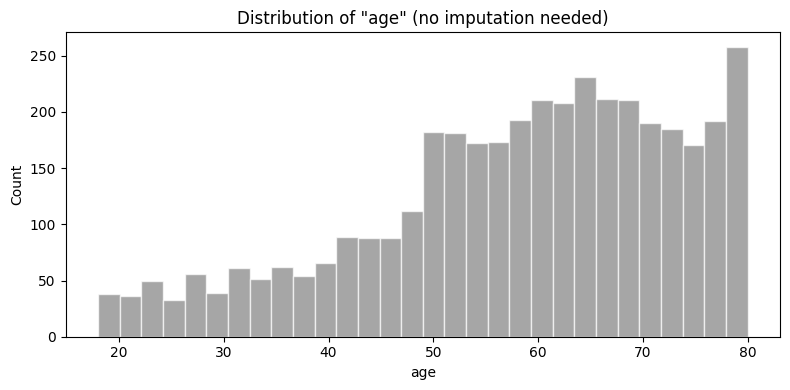

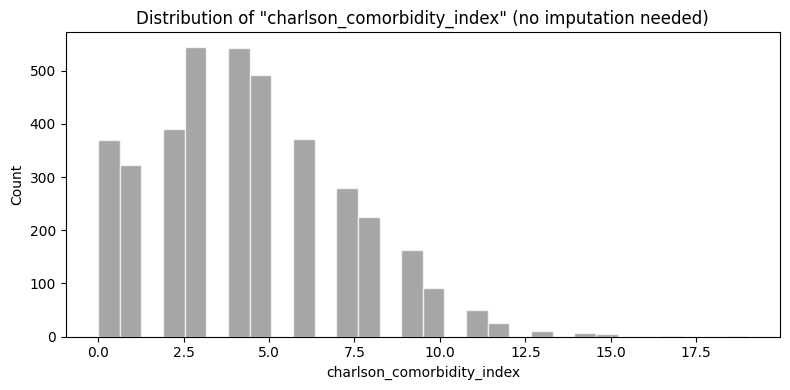

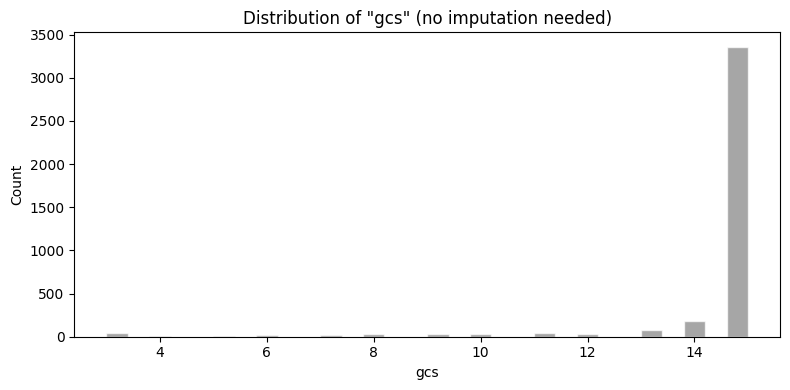

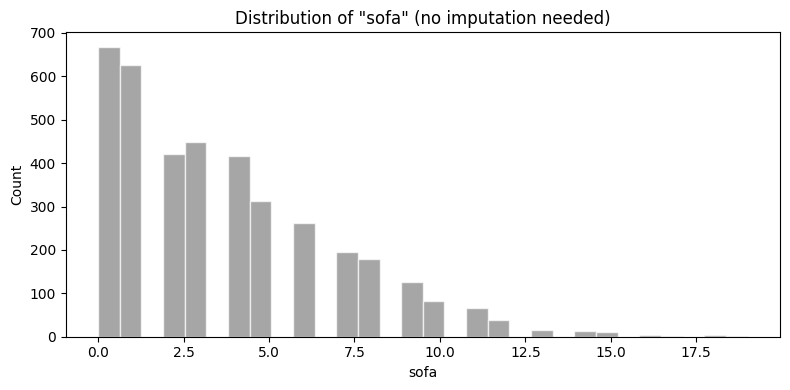

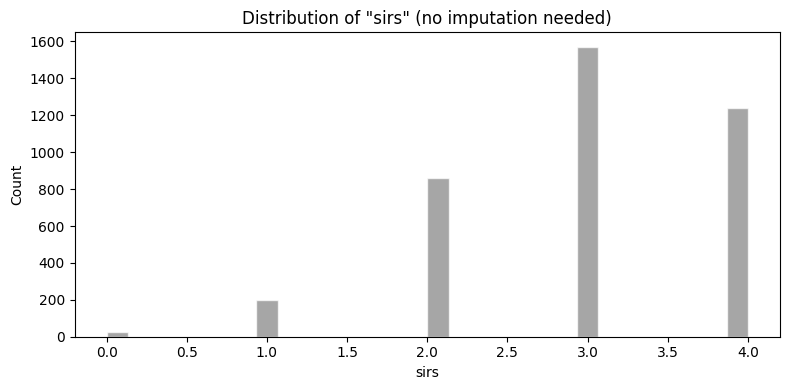

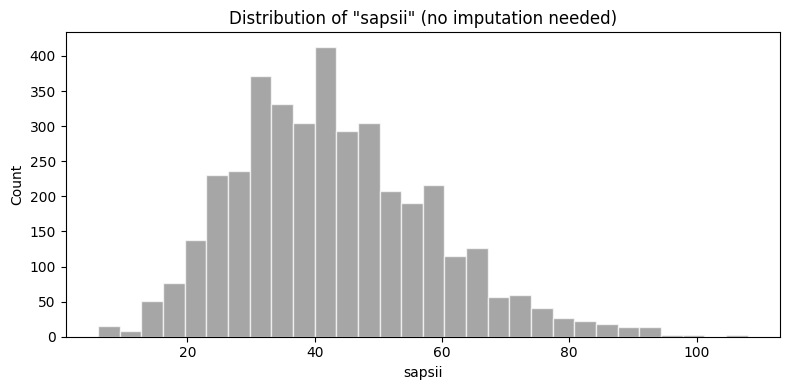

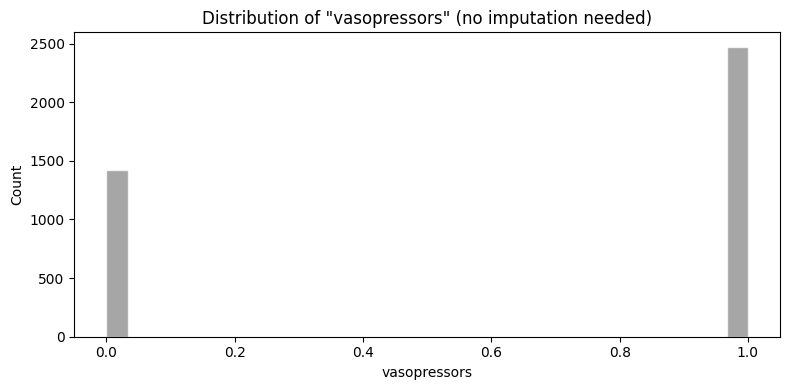

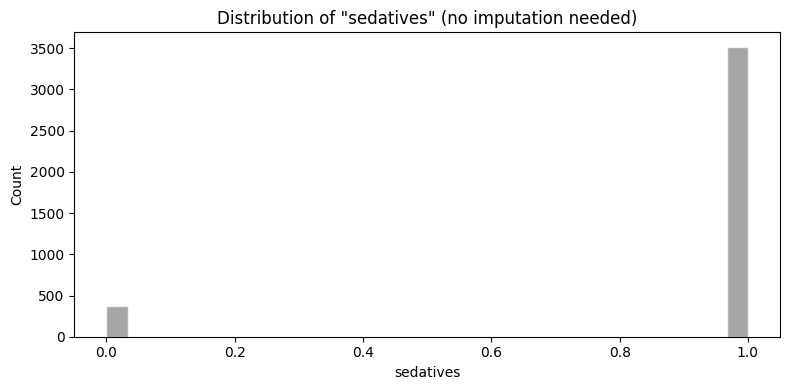

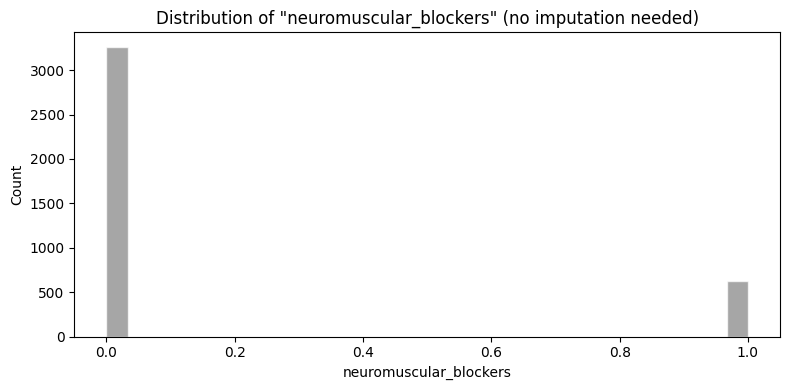

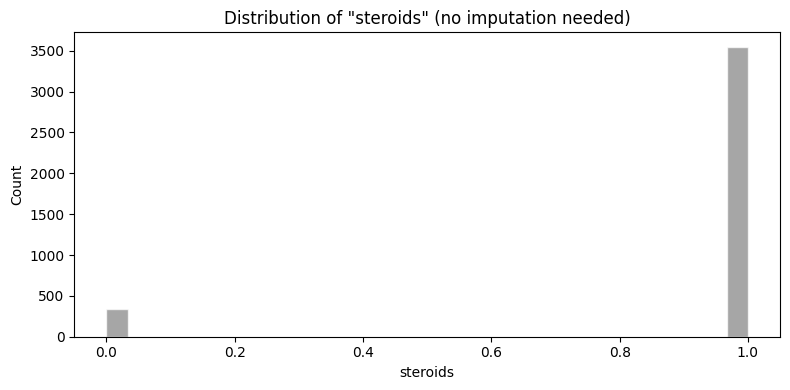

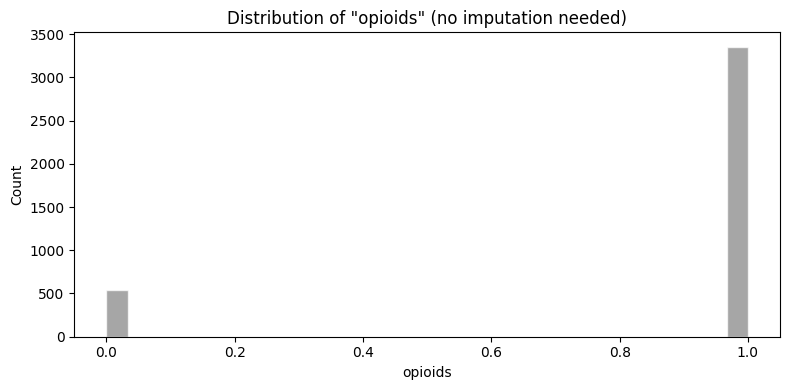

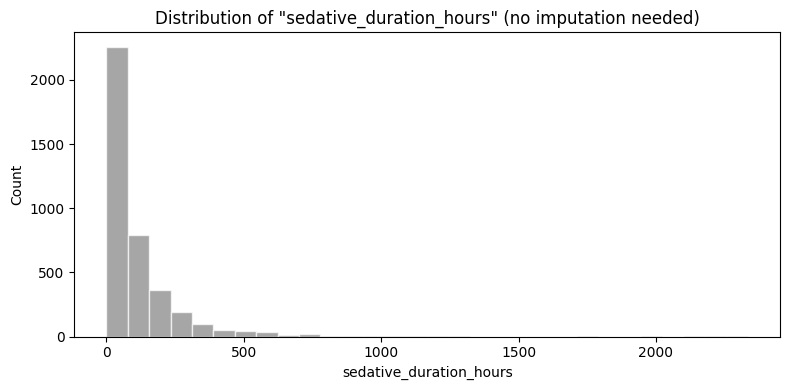

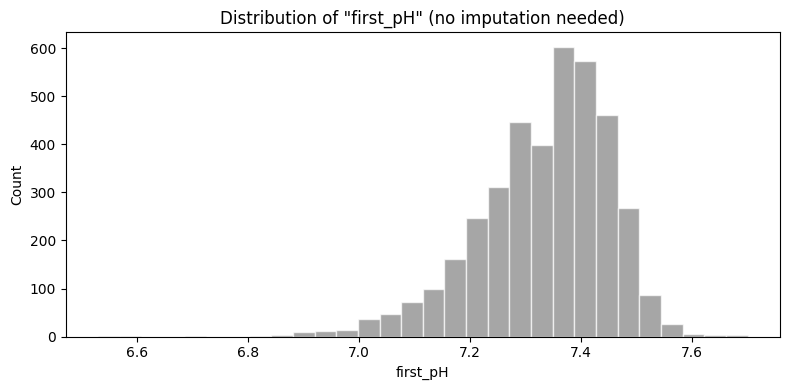

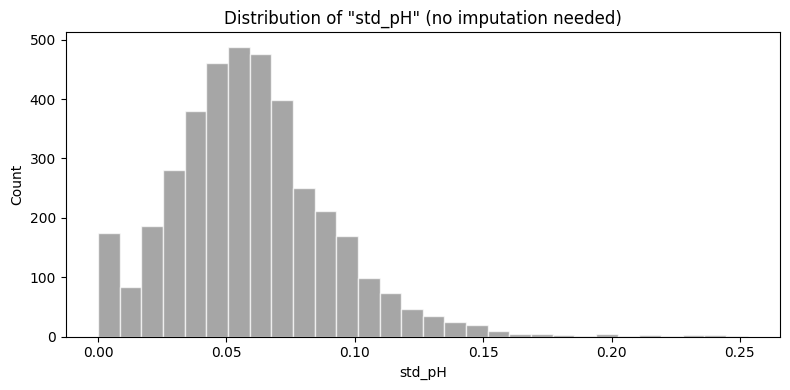

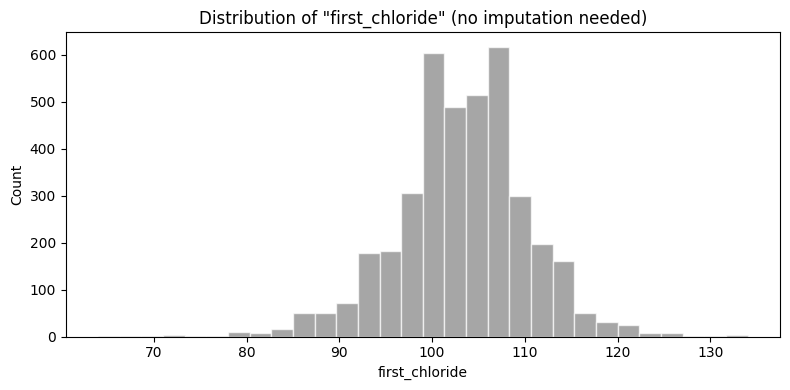

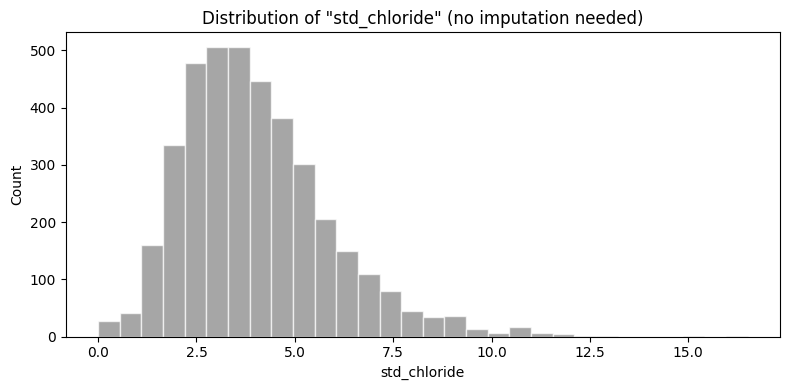

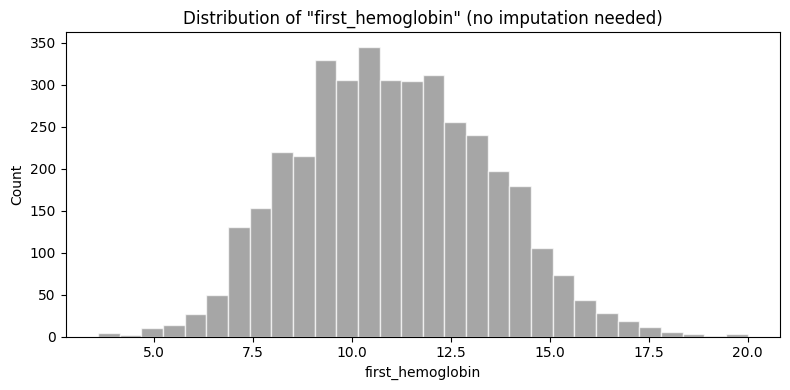

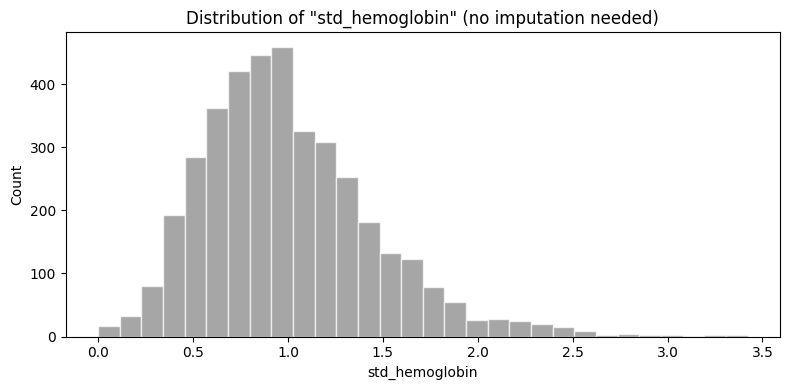

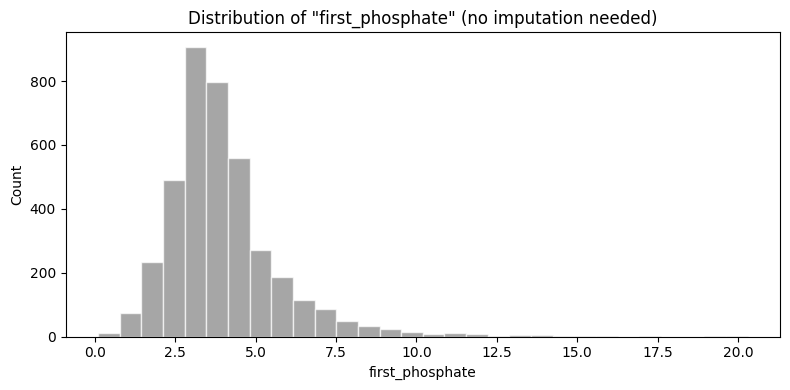

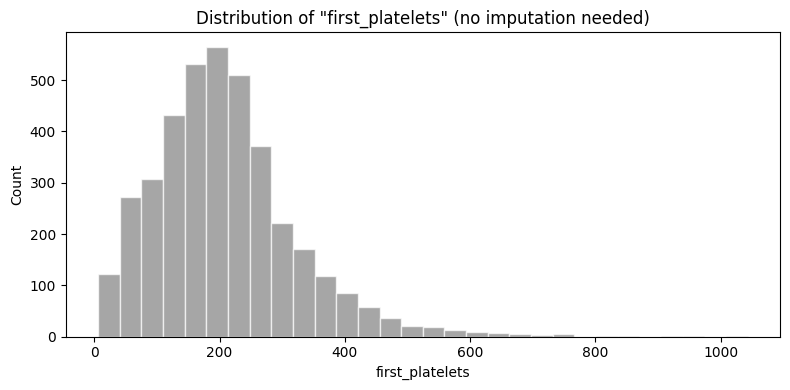

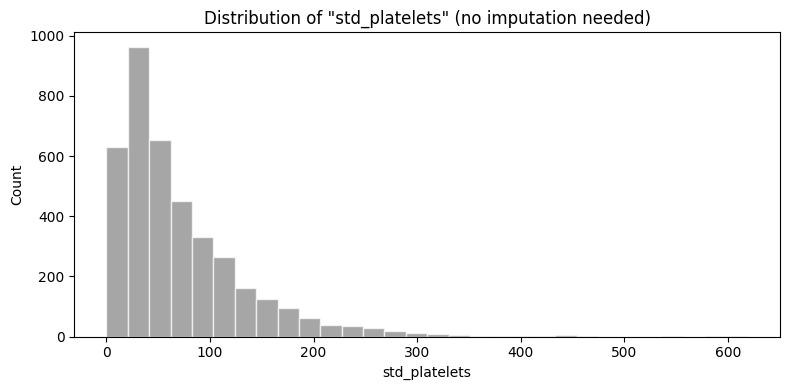

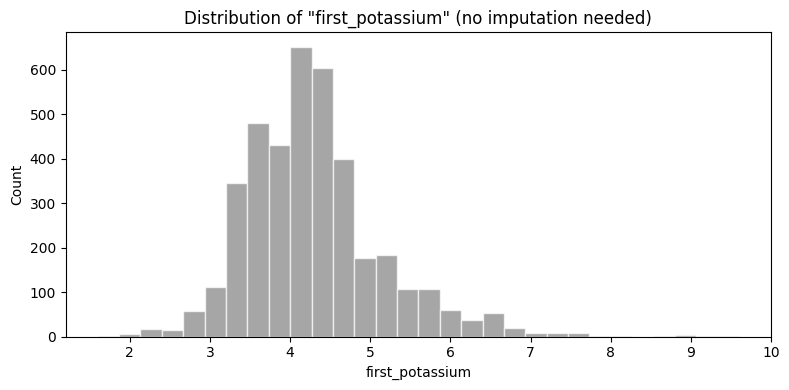

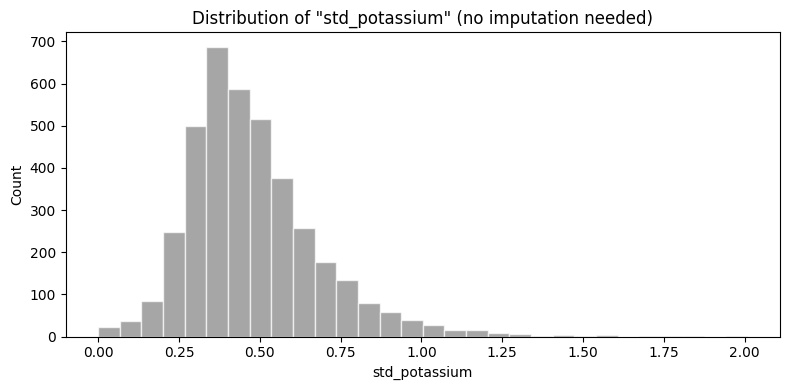

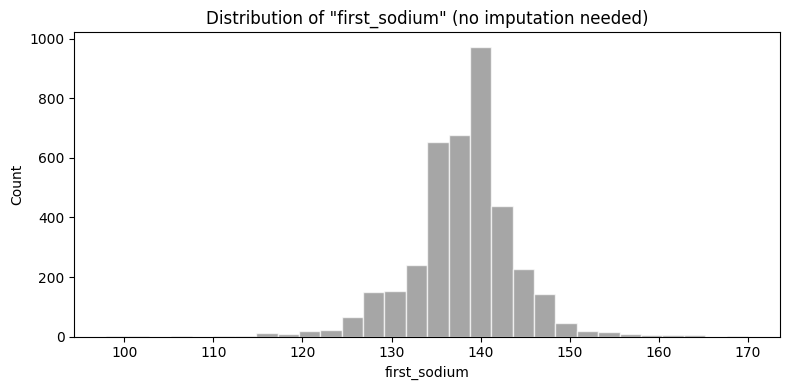

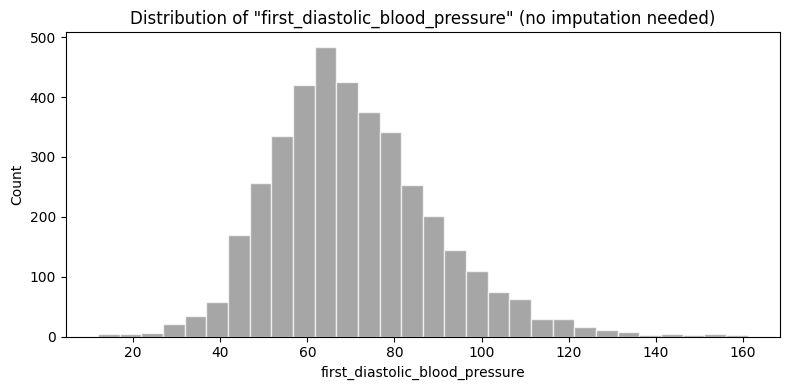

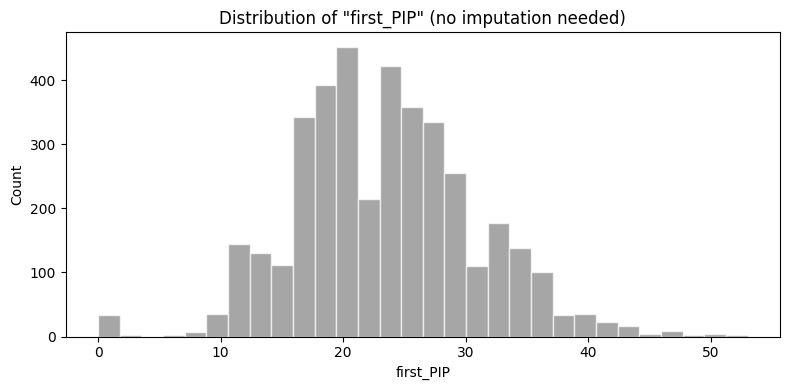

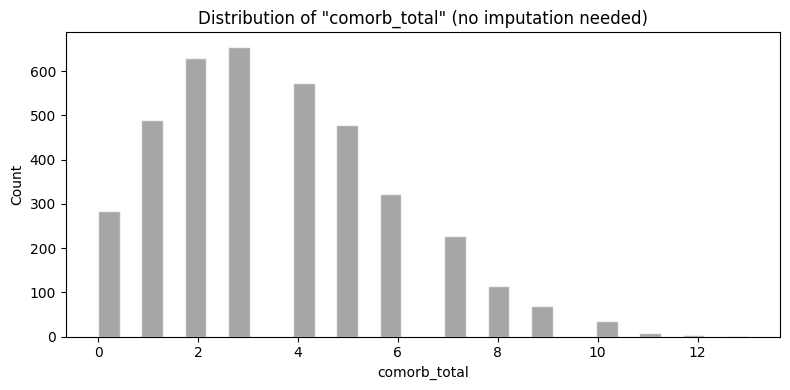

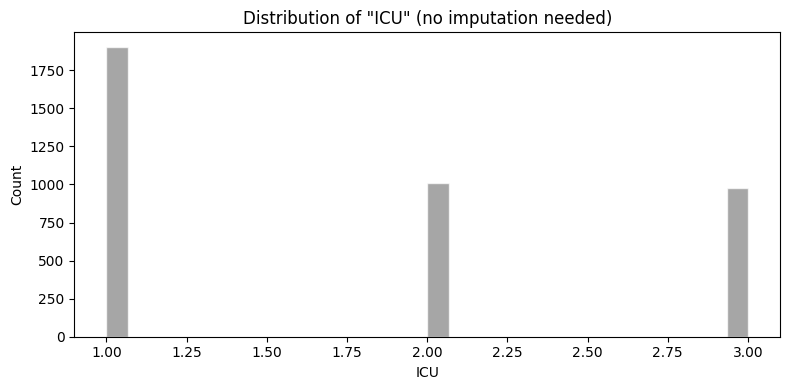

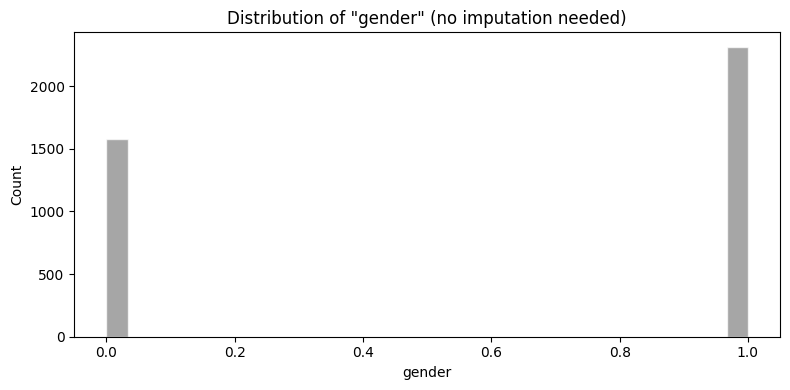

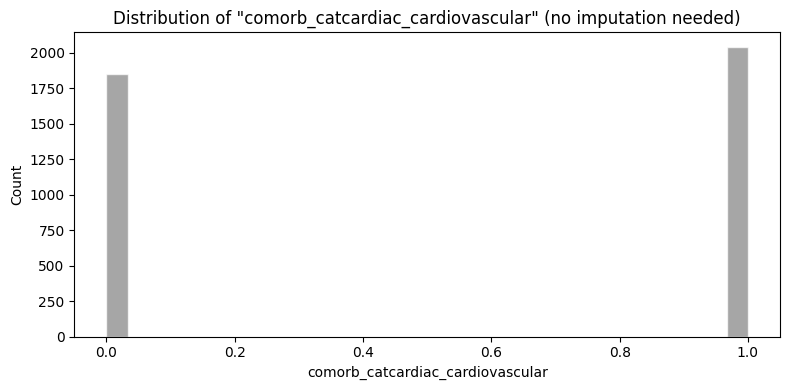

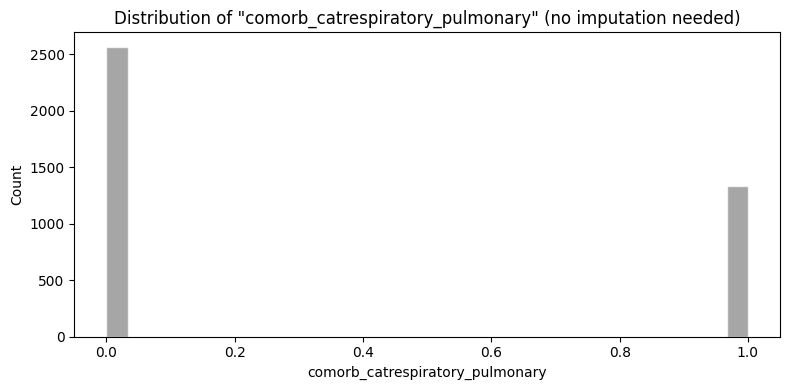

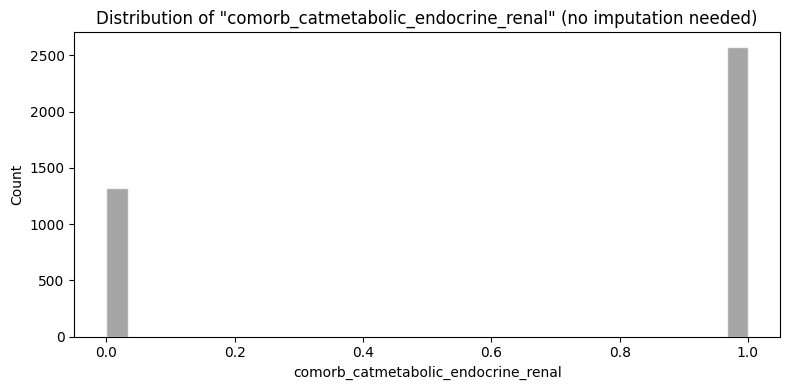

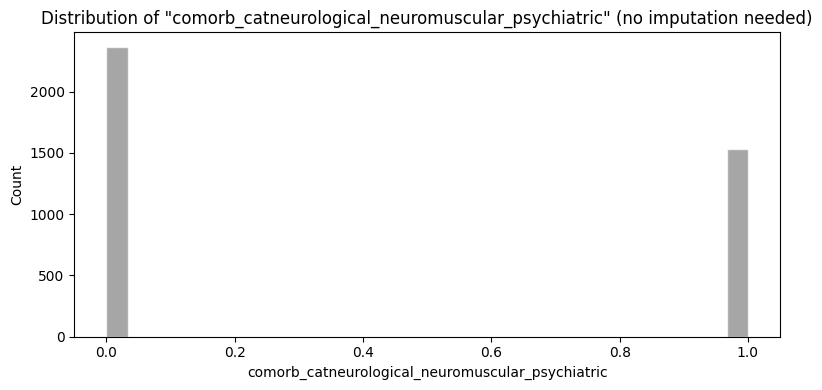

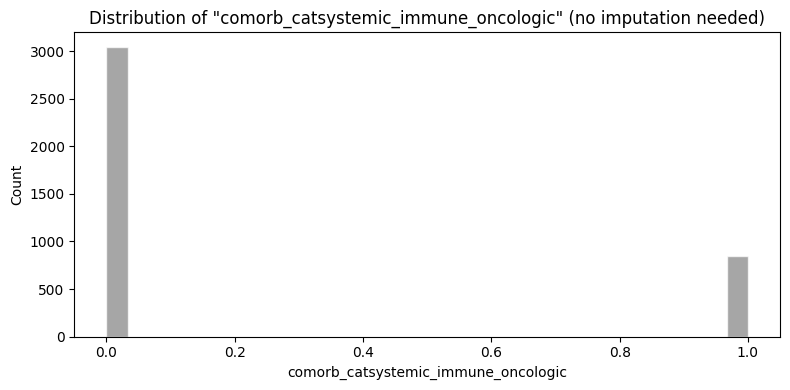

In [8]:
import matplotlib.pyplot as plt

vars_no_mv = [col for col in input_features if not df[col].isna().any()]
print(f'{len(vars_no_mv)} variables without missing values:')
print(vars_no_mv)

for col in vars_no_mv:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.set_title(f'Distribution of "{col}" (no imputation needed)', fontsize=12)
    bins = min(30, max(5, int(len(df[col].dropna()) ** 0.5)))
    ax.hist(df[col].dropna(), bins=bins, color='gray', edgecolor='white', alpha=0.7)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()


In [9]:
# ============================================================
# Split subjects into:
#    - TRS: subjects without missing values
#    - subjects with missing values
# ============================================================

# Extract input feature only
X = df[input_features].copy()

# Split: complete cases (TRS) vs. subjects with missing values
X_trs = X.dropna()
X_missing = X[X.isna().any(axis=1)]

# Check how any subjects are in each set
print("TRS subjects:", X_trs.shape[0])
print("Subjects with MVs:", X_missing.shape[0])

# ============================================================
# 3. Normalize TRS subjects
# ============================================================
scaler = MinMaxScaler()

X_trs_scaled = pd.DataFrame(
    scaler.fit_transform(X_trs),
    columns=X_trs.columns,
    index=X_trs.index
)

TRS subjects: 3378
Subjects with MVs: 515


In [10]:
# ============================================================
# Impute missing values subject by subject
# ============================================================

X_imputed = X.copy()

for subject_idx in X_missing.index:
    subject = X_missing.loc[subject_idx]

    # Get observed variables for distance calculation
    observed_vars = subject.dropna().index.tolist()
    if not observed_vars:
        print(f"Warning: Subject {subject_idx} has all missing values. Skipping.")
        continue

    # Normalize subject
    subject_to_scale = pd.DataFrame([subject.values], columns=subject.index, index=[subject_idx])
    subject_scaled = pd.DataFrame(
        scaler.transform(subject_to_scale),
        columns=X.columns,
        index=[subject_idx]
    )

    # Compute L1 distances on observed variables
    trs_observed = X_trs_scaled[observed_vars]
    subject_observed = subject_scaled.loc[subject_idx, observed_vars]
    distances = (trs_observed - subject_observed).abs().sum(axis=1)

    # Find k-nearest neighbors
    nearest_subjects_indices = distances.nsmallest(k).index
    neighbors = X_trs.loc[nearest_subjects_indices]

    # Impute missing variables
    for var in subject[subject.isna()].index.tolist():
        if var in continuous_vars:
            X_imputed.loc[subject_idx, var] = neighbors[var].mean()
        elif var in integer_vars:
            X_imputed.loc[subject_idx, var] = neighbors[var].median()
        elif var in categorical_vars:
            mode_result = mode(neighbors[var], keepdims=False)
            X_imputed.loc[subject_idx, var] = mode_result.mode if isinstance(mode_result.mode, (int, float, str, np.integer)) else mode_result.mode[0]

# Rebuild final dataset with imputed values
df_final = df.copy()
df_final[input_features] = X_imputed[input_features]


---
## Visualisation: kNN Global Imputation – Imputed Variables

For each variable with at least one missing value, distribution of **all patients** before (complete cases only) vs. after imputation.

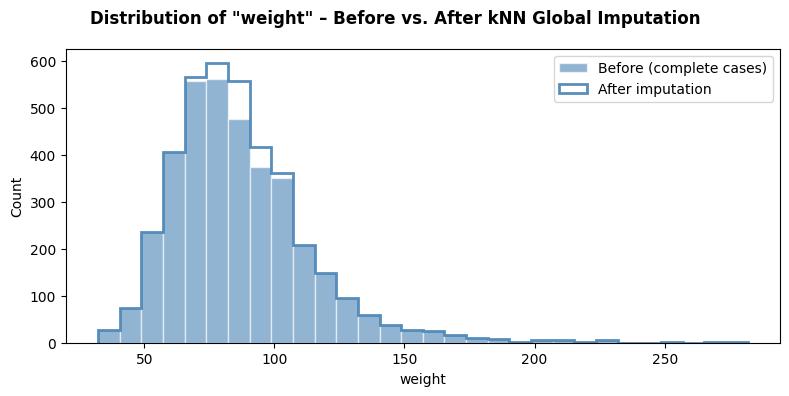

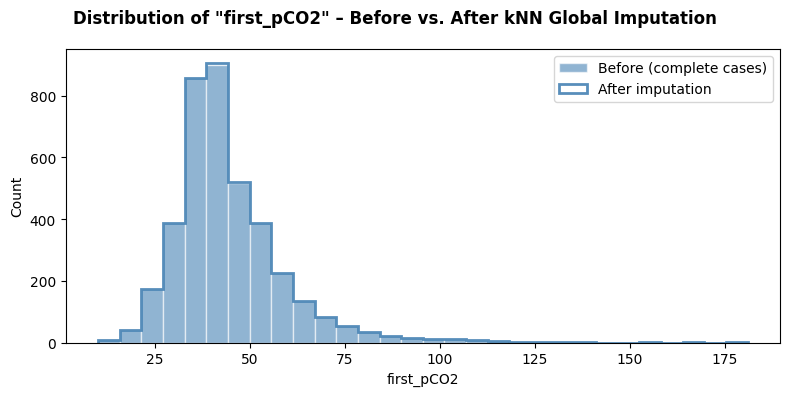

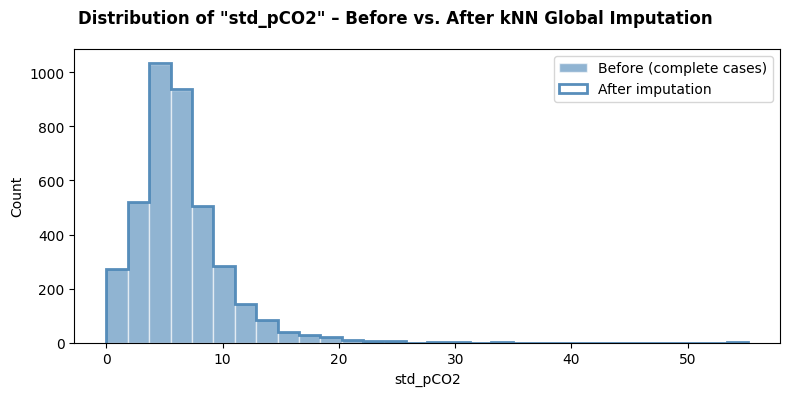

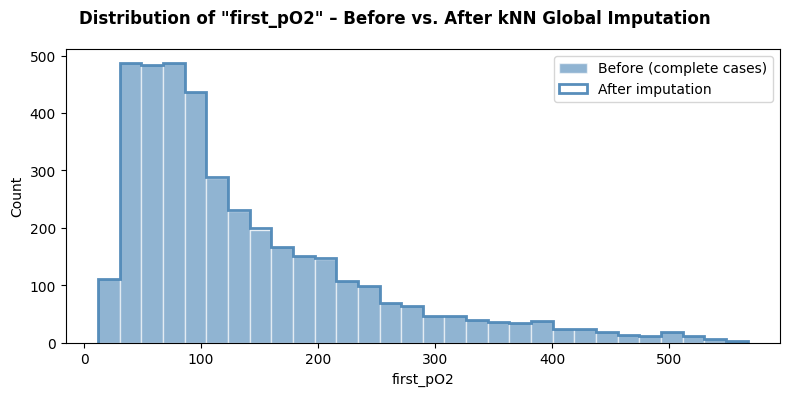

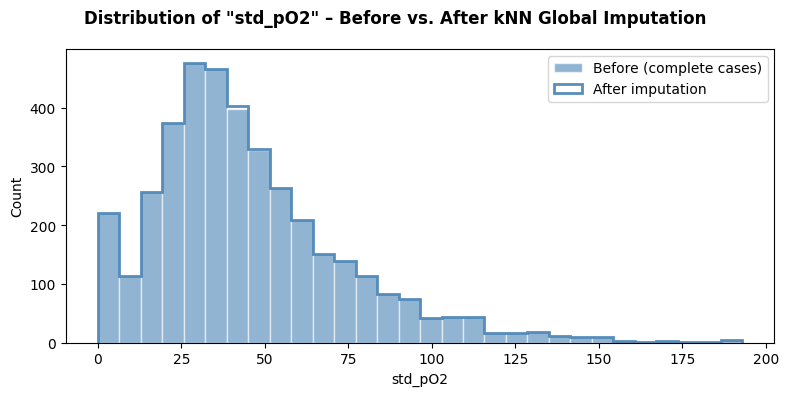

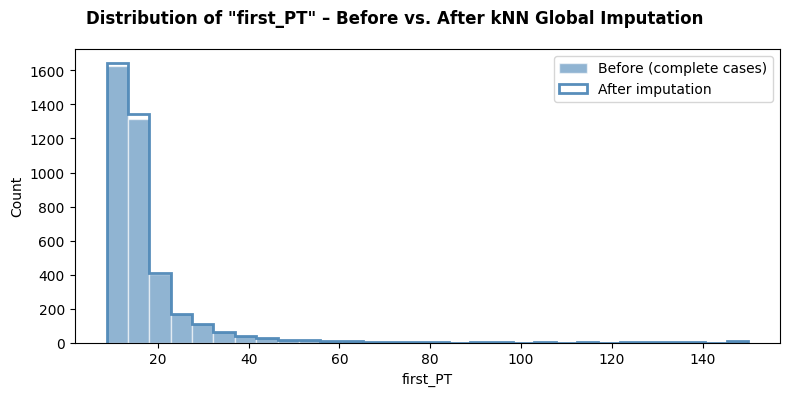

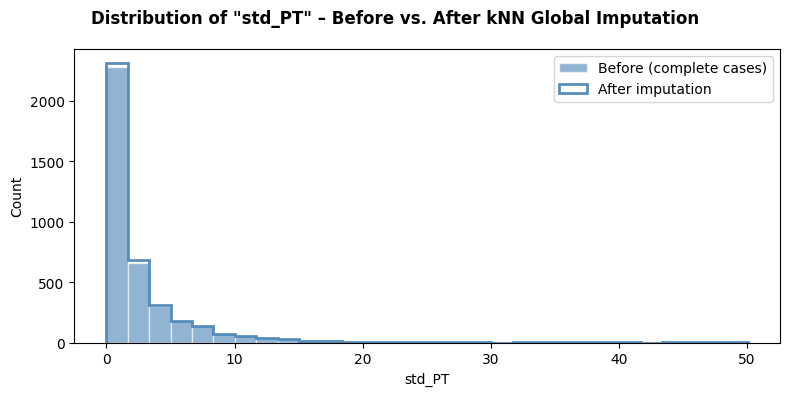

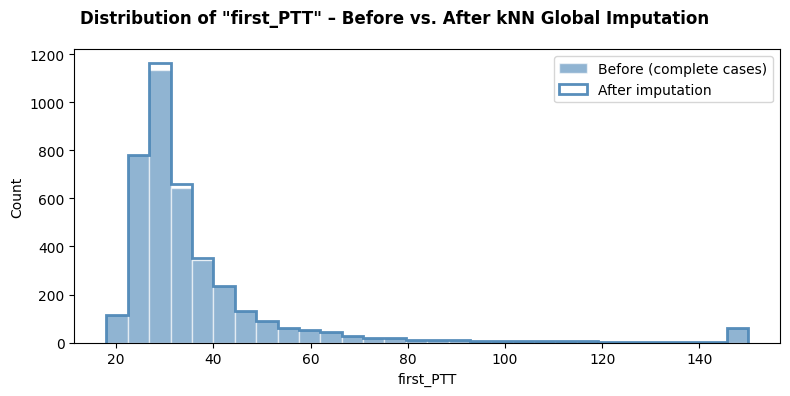

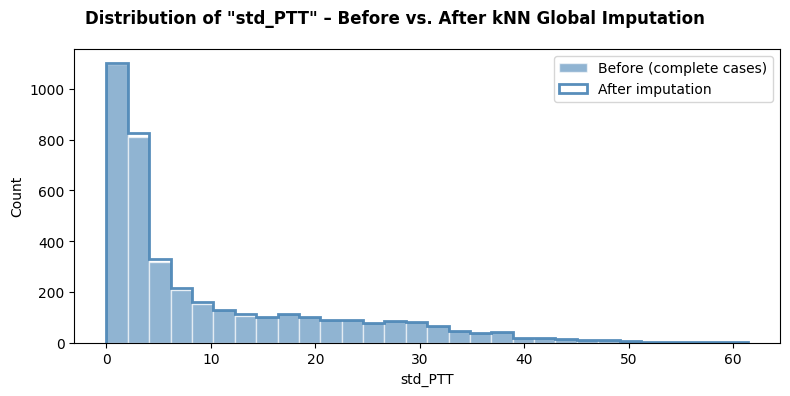

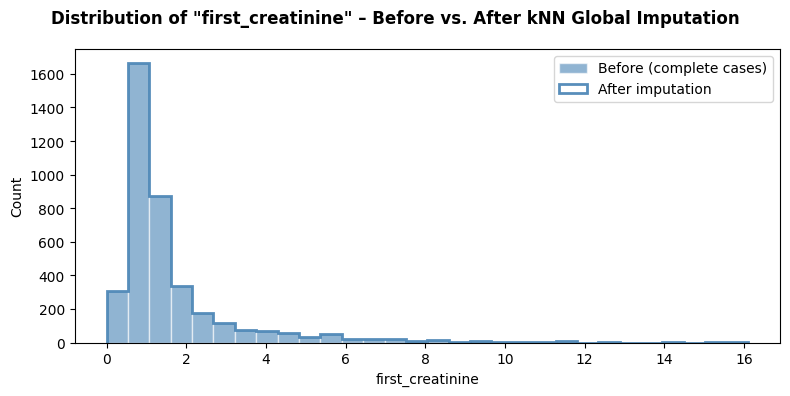

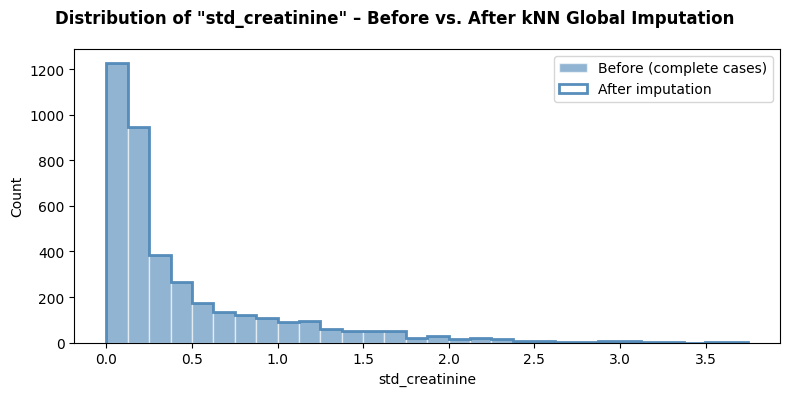

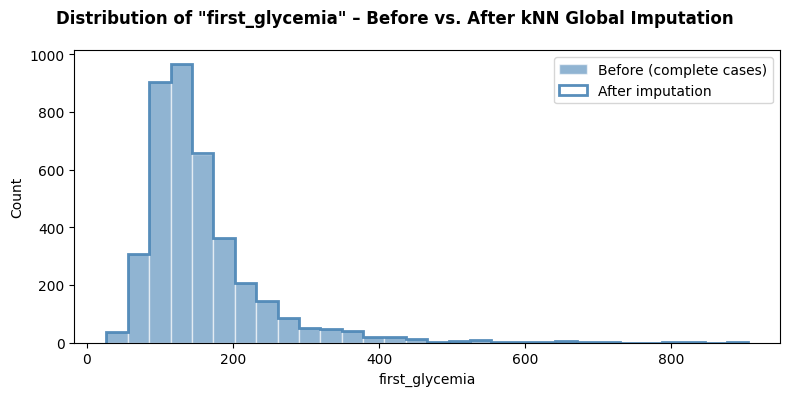

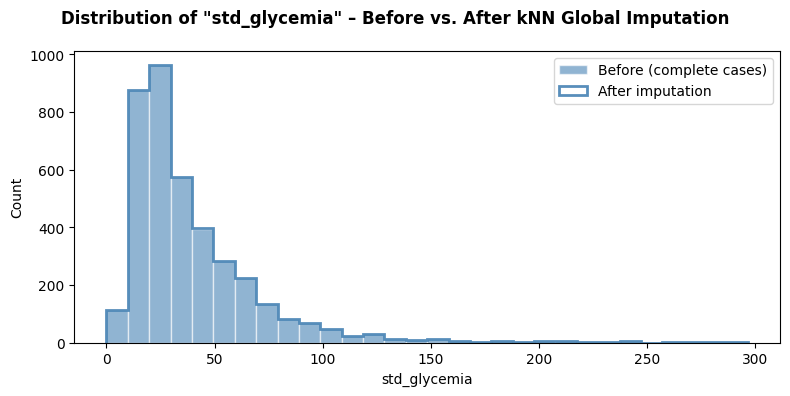

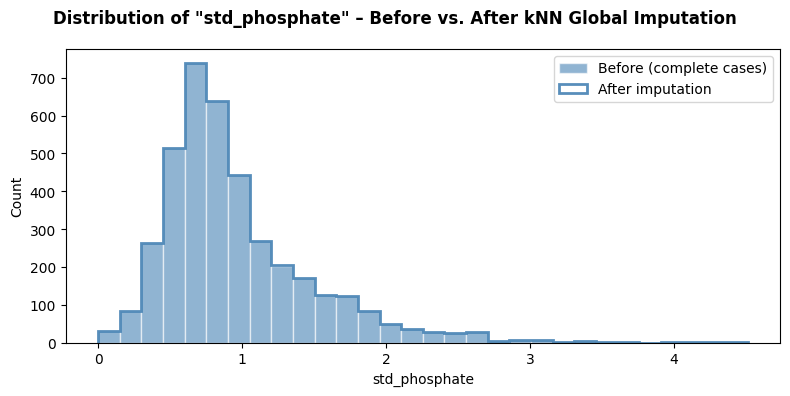

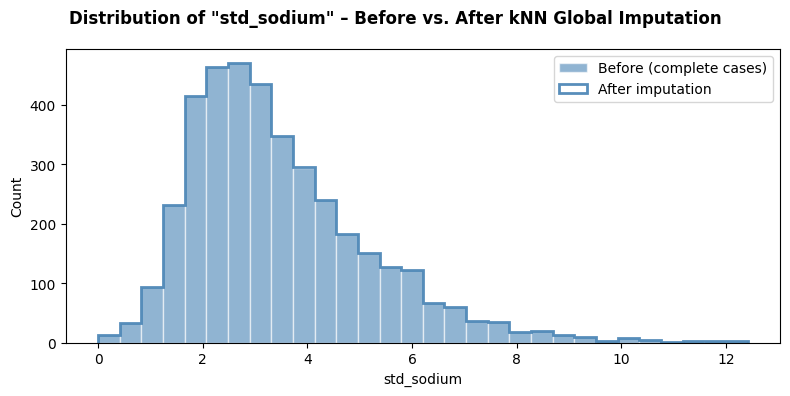

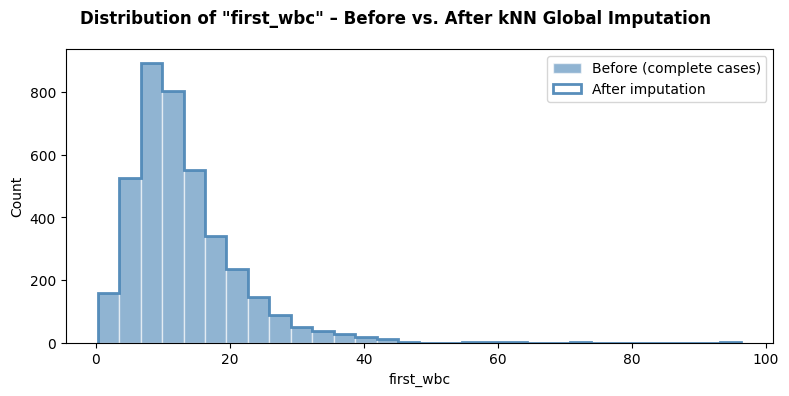

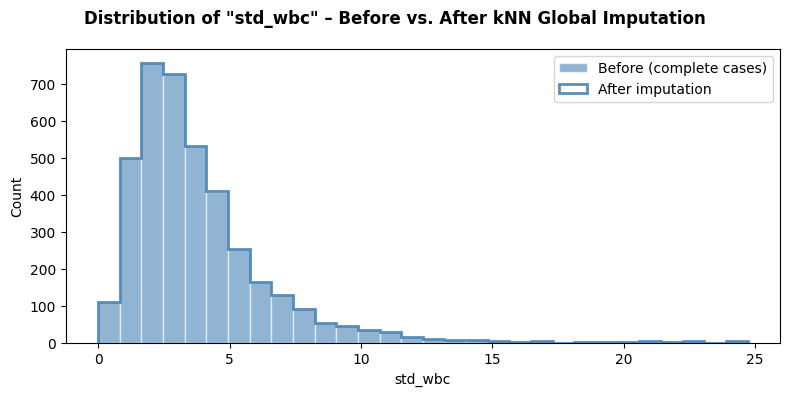

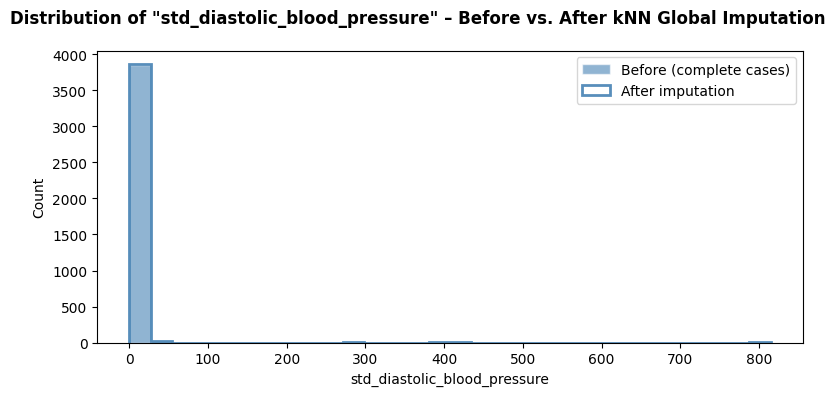

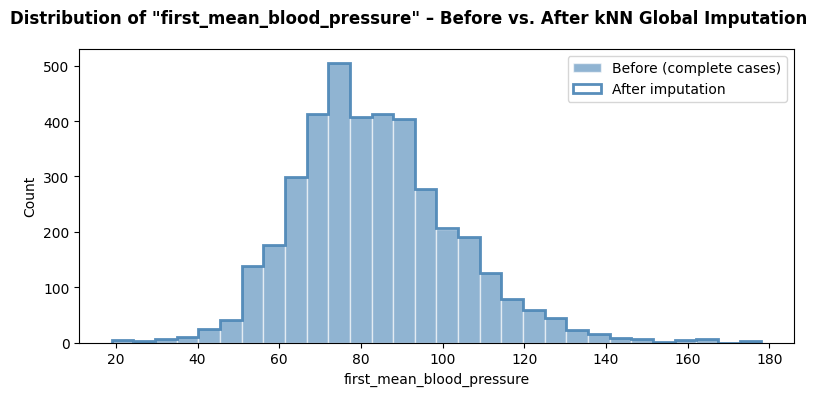

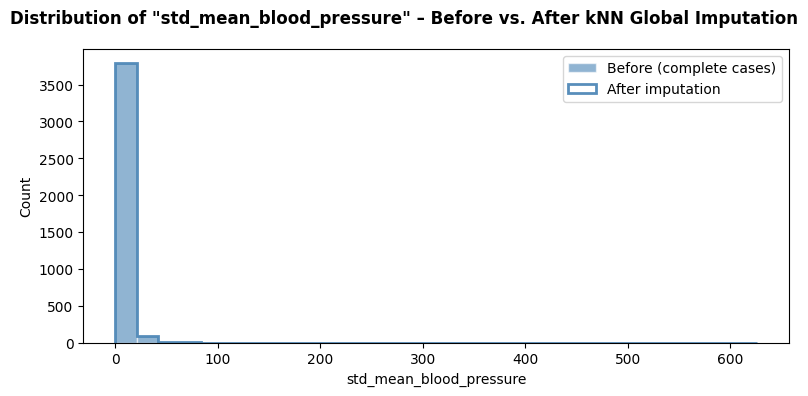

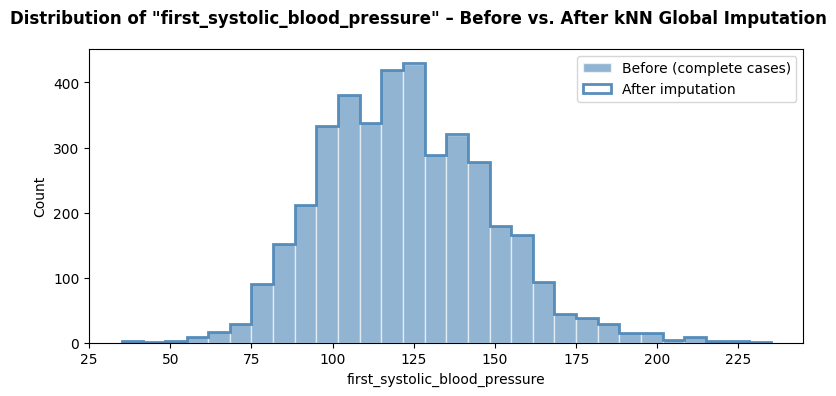

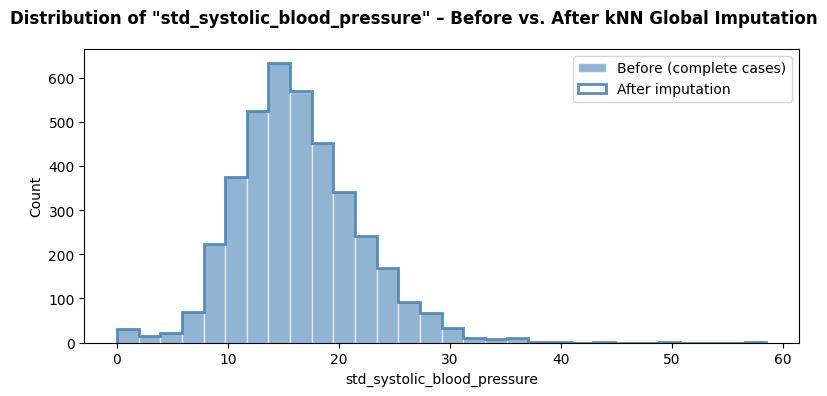

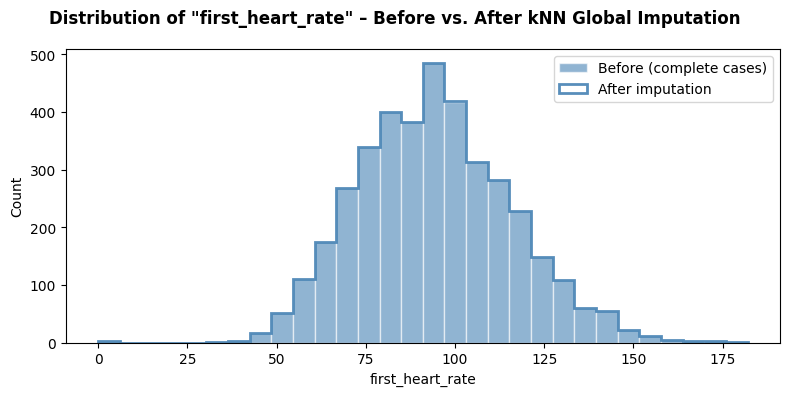

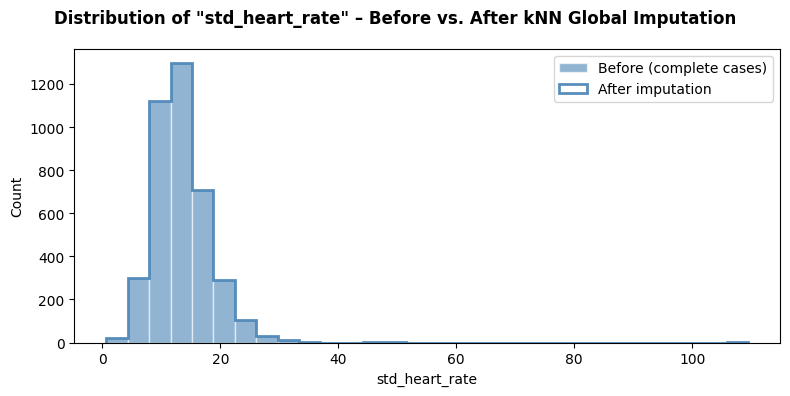

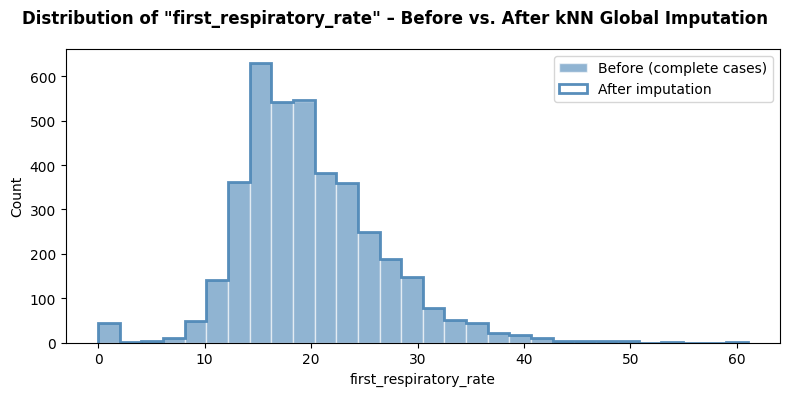

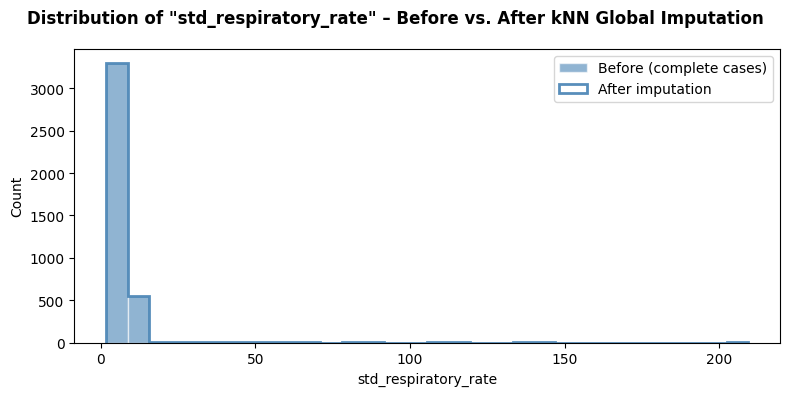

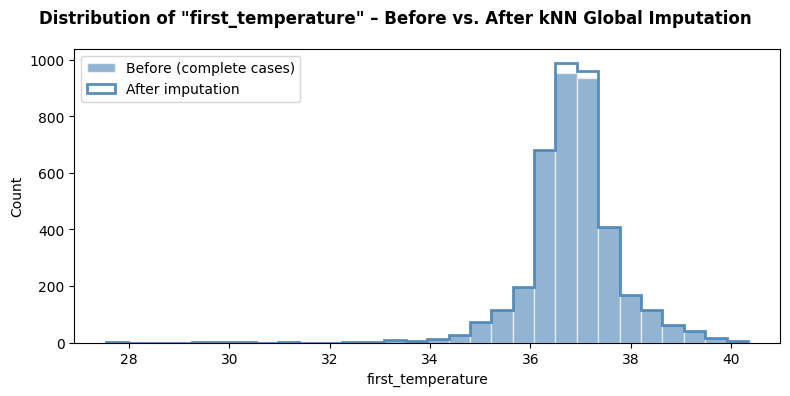

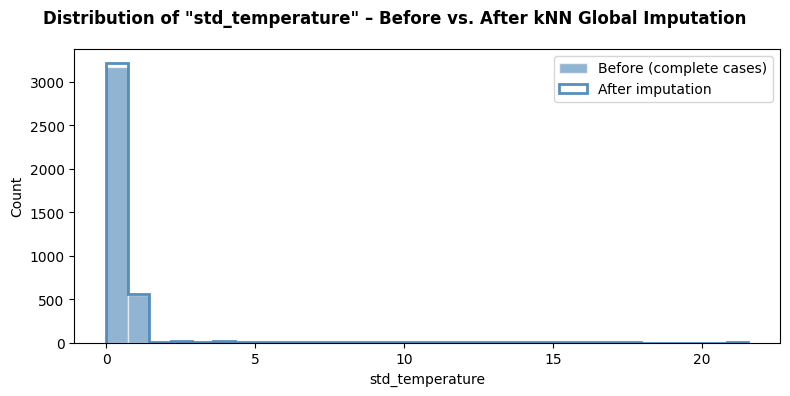

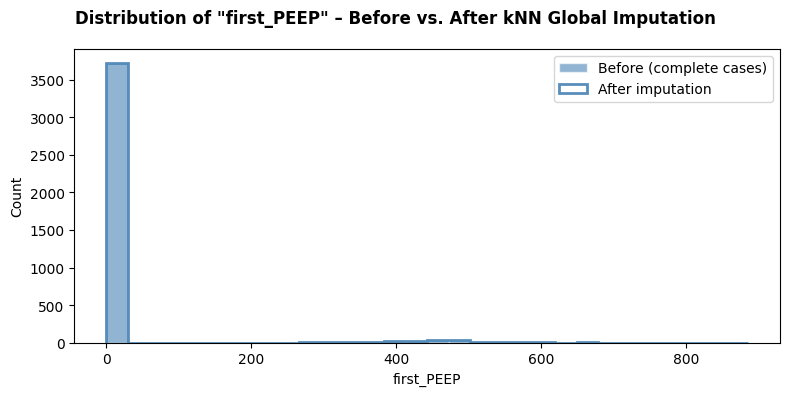

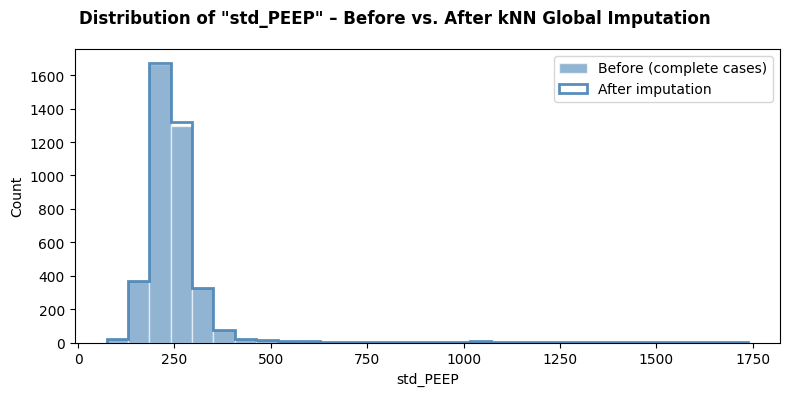

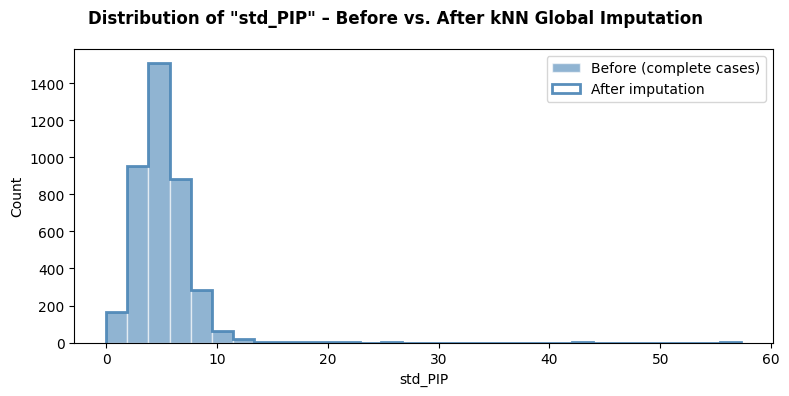

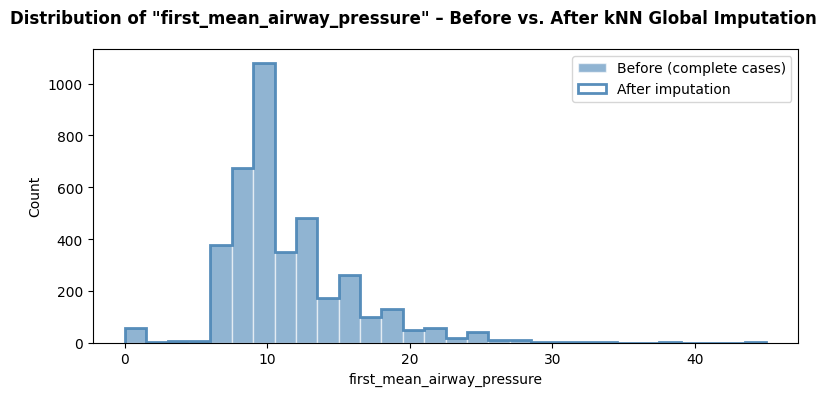

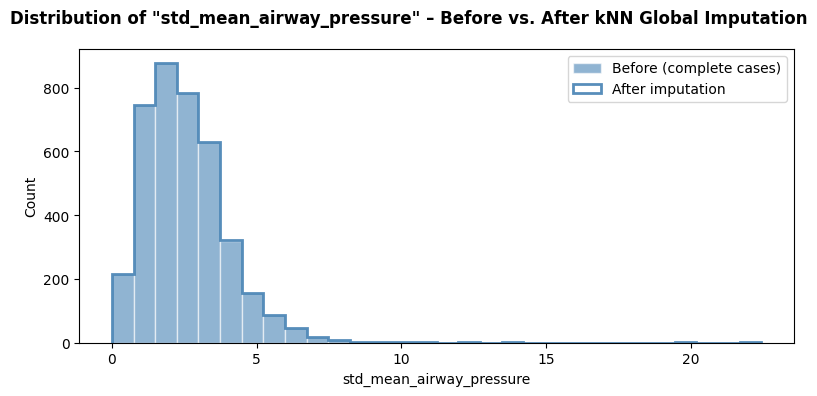

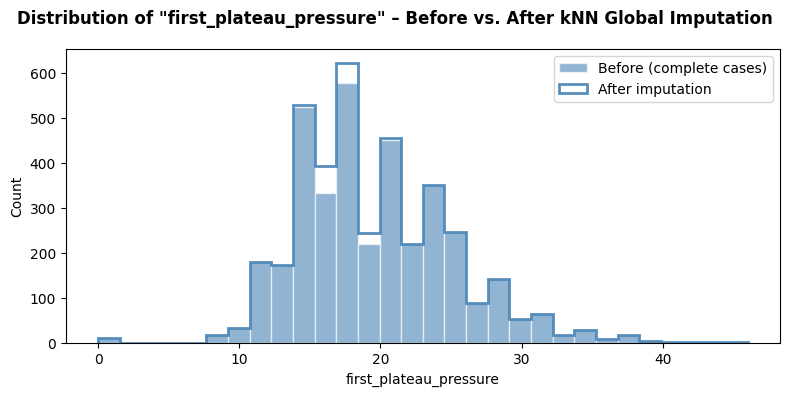

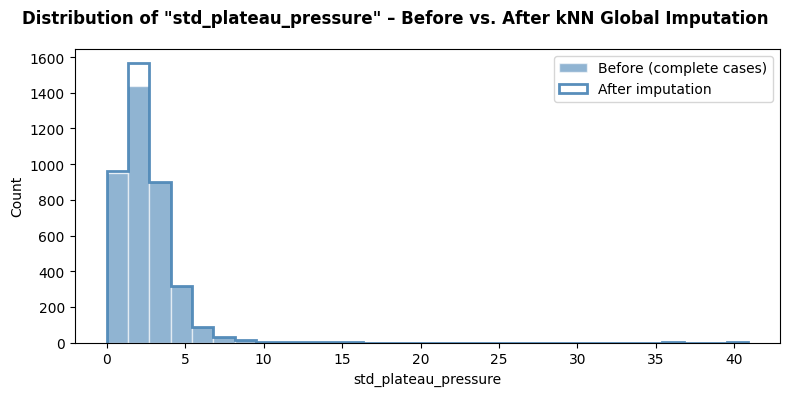

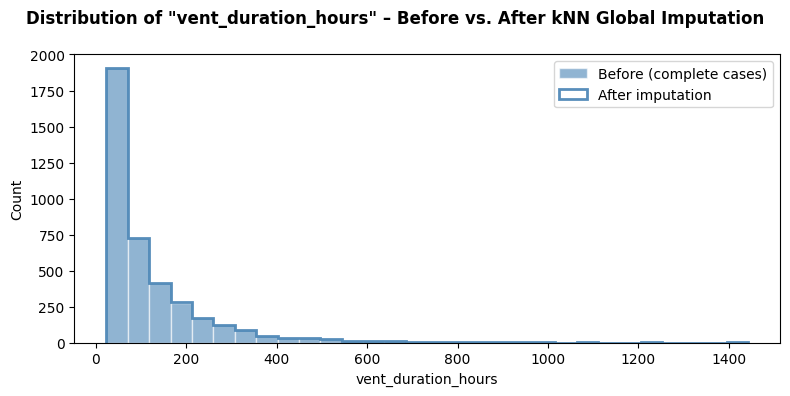

In [11]:
import matplotlib.pyplot as plt

vars_with_mv = [col for col in input_features if df[col].isna().any()]

for col in vars_with_mv:
    fig, ax = plt.subplots(figsize=(8, 4))
    fig.suptitle(
        f'Distribution of "{col}" – Before vs. After kNN Global Imputation',
        fontsize=12, fontweight='bold'
    )
    before = df[col].dropna()
    after  = df_final[col].dropna()
    bins = min(30, max(5, int(len(after) ** 0.5)))
    ax.hist(before, bins=bins, alpha=0.6, color='steelblue',
            label='Before (complete cases)', edgecolor='white')
    ax.hist(after,  bins=bins, alpha=0.9, color='steelblue',
            label='After imputation', histtype='step', linewidth=2)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend()
    plt.tight_layout()
    plt.show()


## 5) Final saving

In [12]:
# Report: missing values before vs after imputation
print("=" * 60)
print("BEFORE Imputation")
print("=" * 60)
print(f"Total missing values: {X.isna().sum().sum()}")
print(f"Subjects with at least one MV: {X.isna().any(axis=1).sum()}")

missing_before = pd.DataFrame({
    "missing_count": X.isna().sum(),
    "missing_%": (X.isna().mean() * 100).round(2)
})
missing_before = missing_before[missing_before["missing_count"] > 0].sort_values("missing_%", ascending=False)
print("\nMissing values per feature:")
display(missing_before)

print("\n" + "=" * 60)
print("AFTER Imputation")
print("=" * 60)
print(f"Total missing values: {X_imputed.isna().sum().sum()}")
print(f"Subjects with at least one MV: {X_imputed.isna().any(axis=1).sum()}")

missing_after = pd.DataFrame({
    "missing_count": X_imputed.isna().sum(),
    "missing_%": (X_imputed.isna().mean() * 100).round(2)
})
missing_after = missing_after[missing_after["missing_count"] > 0]
if len(missing_after) > 0:
    print("\nRemaining missing values per feature:")
    display(missing_after)
else:
    print("\n✓ All missing values have been imputed successfully!")

BEFORE Imputation
Total missing values: 906
Subjects with at least one MV: 515

Missing values per feature:


,missing_count,missing_%
weight,177,4.55
std_plateau_pressure,140,3.60
first_plateau_pressure,137,3.52
first_temperature,58,1.49
first_PTT,57,1.46
std_PTT,57,1.46
std_PT,54,1.39
first_PT,53,1.36
std_temperature,53,1.36
std_PEEP,34,0.87



AFTER Imputation
Total missing values: 0
Subjects with at least one MV: 0

✓ All missing values have been imputed successfully!


In [13]:
# Save the globally imputed dataset to Excel
new_sheet_name_global = "Dataset_step_3a"
with pd.ExcelWriter(file_path, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
    df_final.to_excel(writer, sheet_name=new_sheet_name_global, index=False)
print(f"Globally imputed dataset saved to '{new_sheet_name_global}'")

Globally imputed dataset saved to 'Dataset_step_3a'


---
## kNN Imputation by Outcome Class

In this section we perform kNN imputation **separately for each outcome class (0 / 1 / 2)**.

Why?
- Patients from different outcome classes may have different clinical distributions.
- Imputing within class preserves intra-class similarity.


In [14]:
# Perform kNN imputation separately for each outcome class
imputed_dfs_by_class = []
outcome_classes = df['outcome'].unique()
print("Outcome classes:", outcome_classes)

for outcome_class in outcome_classes:
    print(f"\nProcessing class {outcome_class}...")

    # Filter and extract features by class
    df_class = df[df['outcome'] == outcome_class].copy()
    X_class = df_class[input_features]

    # Split: complete cases (TRS) vs. subjects with missing values
    X_trs_class = X_class.dropna()
    X_missing_class = X_class[X_class.isna().any(axis=1)]

    print(f"  TRS: {X_trs_class.shape[0]} | Missing: {X_missing_class.shape[0]}")

    # Handle edge cases (no missing or no TRS)
    if X_missing_class.empty or X_trs_class.empty:
        imputed_dfs_by_class.append(X_class)
        continue

    # Normalize TRS for this class
    scaler_class = MinMaxScaler()
    X_trs_scaled_class = pd.DataFrame(
        scaler_class.fit_transform(X_trs_class),
        columns=X_trs_class.columns,
        index=X_trs_class.index
    )

    X_imputed_class = X_class.copy()

    # Impute missing values within class
    for subject_idx in X_missing_class.index:
        subject = X_missing_class.loc[subject_idx]
        observed_vars = subject.dropna().index.tolist()

        if not observed_vars:
            print(f"  Subject {subject_idx} has no observed variables. Skipping.")
            continue

        # Normalize and find neighbors
        subject_to_scale = pd.DataFrame([subject.values], columns=subject.index, index=[subject_idx])
        subject_scaled = pd.DataFrame(
            scaler_class.transform(subject_to_scale),
            columns=X_class.columns,
            index=[subject_idx]
        )

        trs_observed = X_trs_scaled_class[observed_vars]
        subject_observed = subject_scaled.loc[subject_idx, observed_vars]
        distances = (trs_observed - subject_observed).abs().sum(axis=1)

        # Adapt k if insufficient neighbors
        num_neighbors = min(k, X_trs_class.shape[0])
        if num_neighbors == 0:
            print(f"  No TRS available for subject {subject_idx}. Skipping.")
            continue

        neighbors = X_trs_class.loc[distances.nsmallest(num_neighbors).index]

        # Impute based on feature type
        for var in subject[subject.isna()].index.tolist():
            if var in continuous_vars:
                X_imputed_class.loc[subject_idx, var] = neighbors[var].mean()
            elif var in integer_vars:
                X_imputed_class.loc[subject_idx, var] = neighbors[var].median()
            elif var in categorical_vars:
                mode_result = mode(neighbors[var], keepdims=False)
                X_imputed_class.loc[subject_idx, var] = mode_result.mode if isinstance(mode_result.mode, (int, float, str, np.integer)) else mode_result.mode[0]

    imputed_dfs_by_class.append(X_imputed_class)

# Merge and rebuild final dataset
X_imputed_all_classes = pd.concat(imputed_dfs_by_class).sort_index()
df_final_by_class = df.copy()
df_final_by_class[input_features] = X_imputed_all_classes[input_features]

Outcome classes: [2 1 0]

Processing class 2...
  TRS: 1024 | Missing: 145

Processing class 1...
  TRS: 1654 | Missing: 294

Processing class 0...
  TRS: 700 | Missing: 76


---
## Visualisation: kNN by-Class Imputation – Imputed Variables

For each variable with at least one missing value, distribution **per outcome class** before (complete cases only) vs. after imputation.

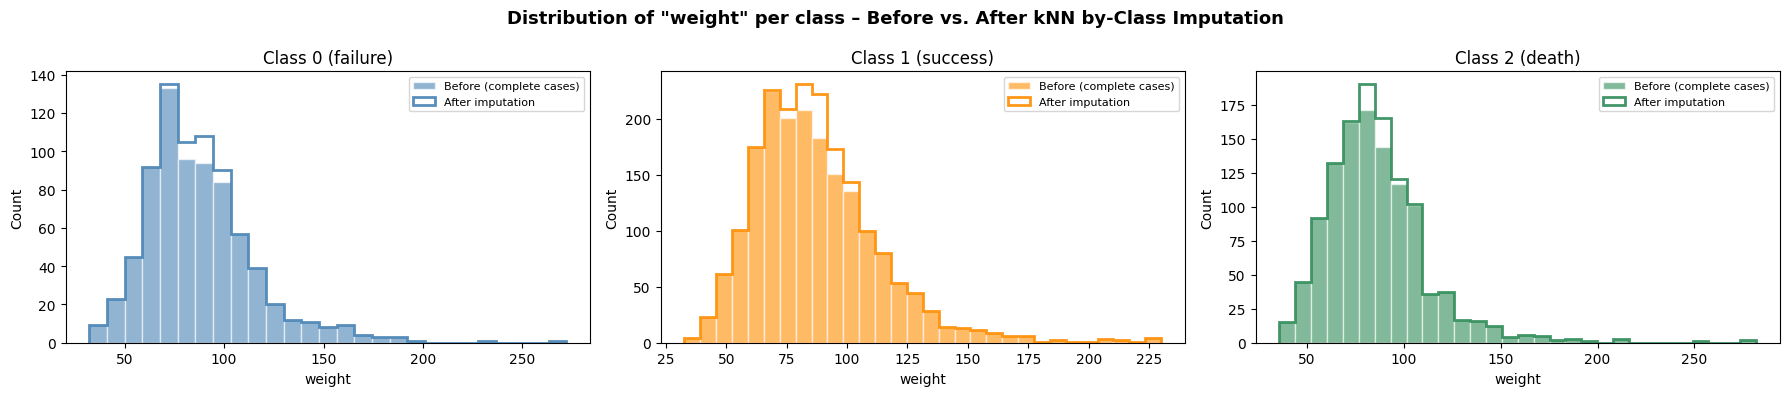

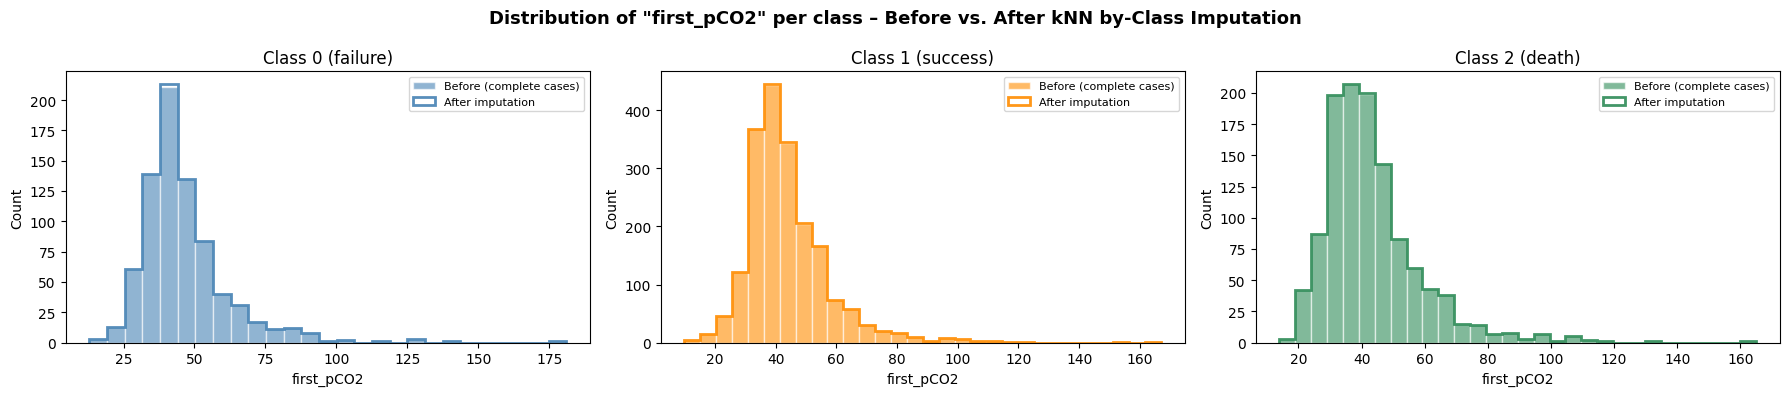

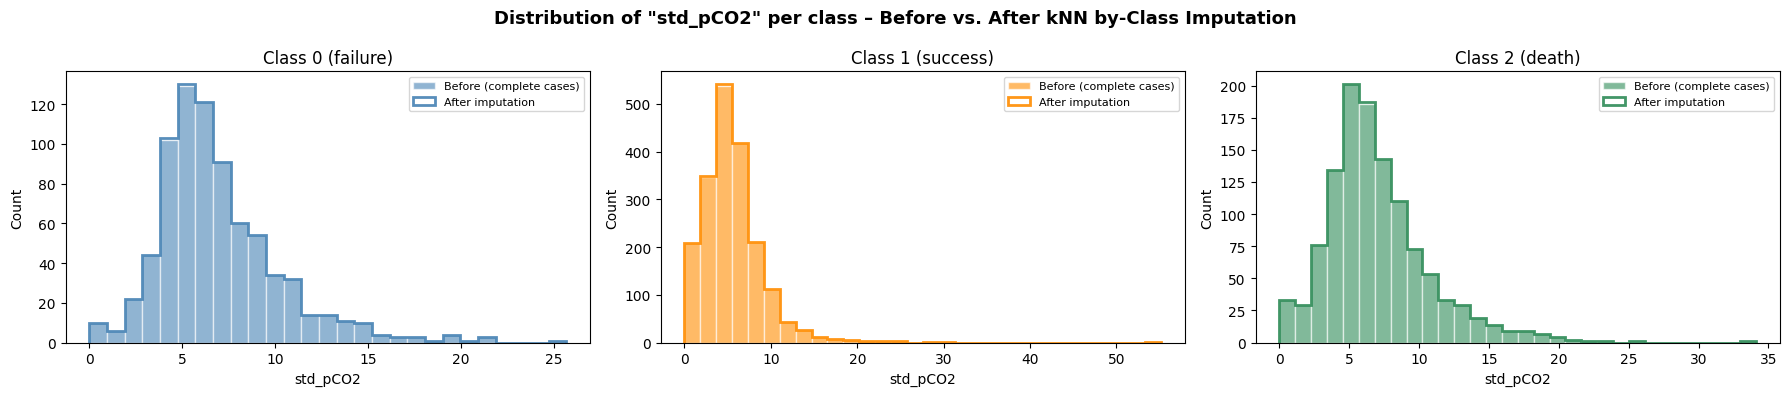

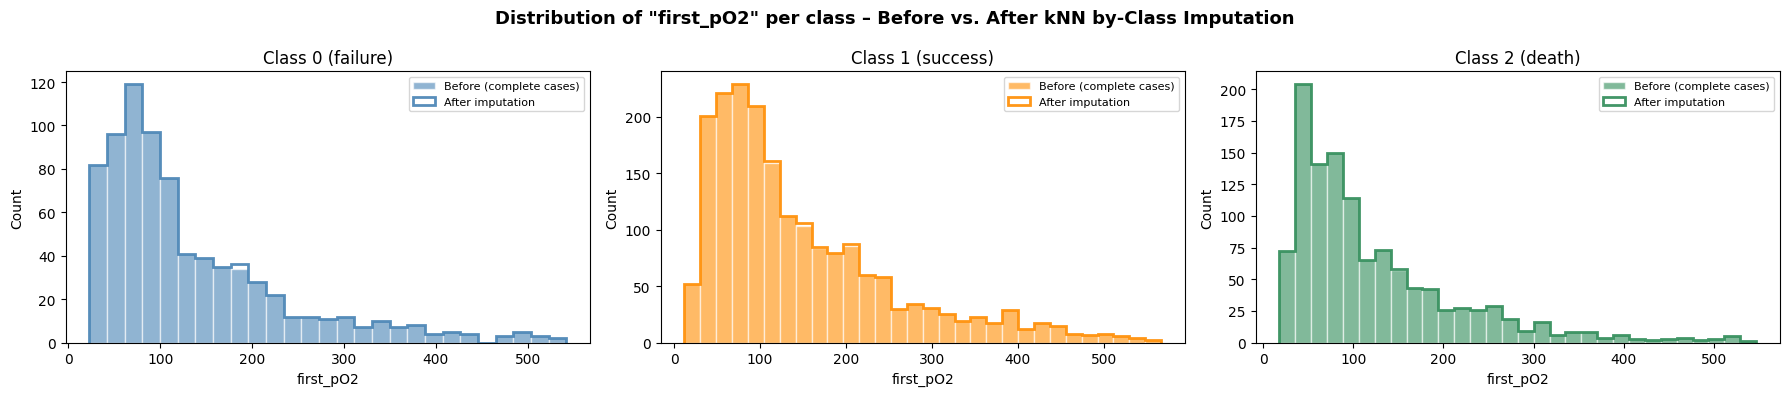

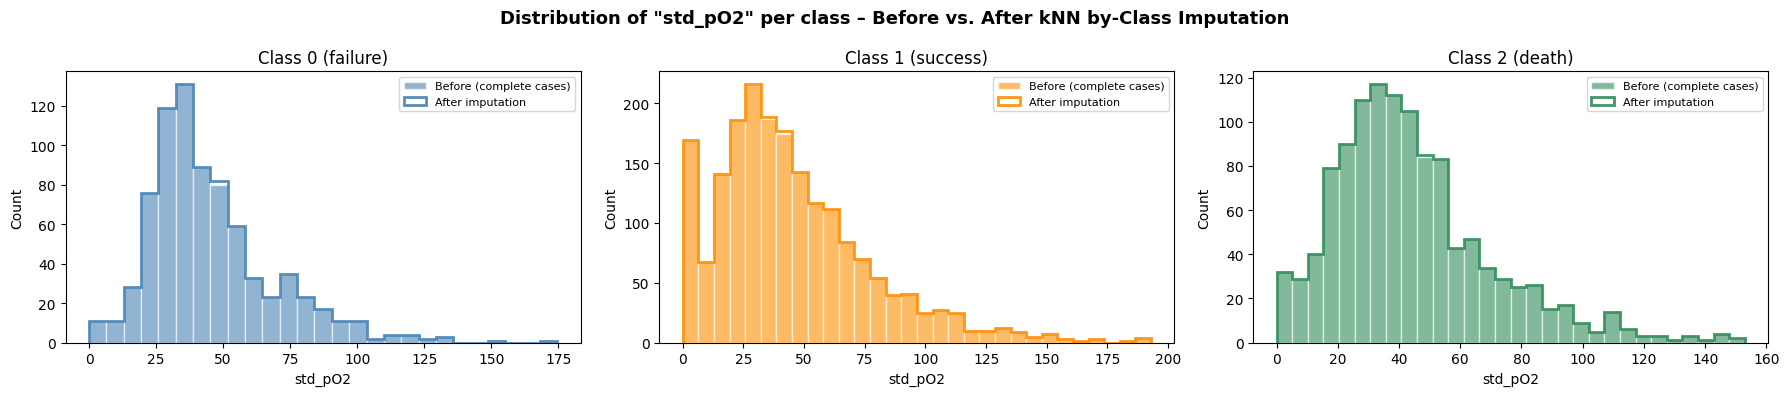

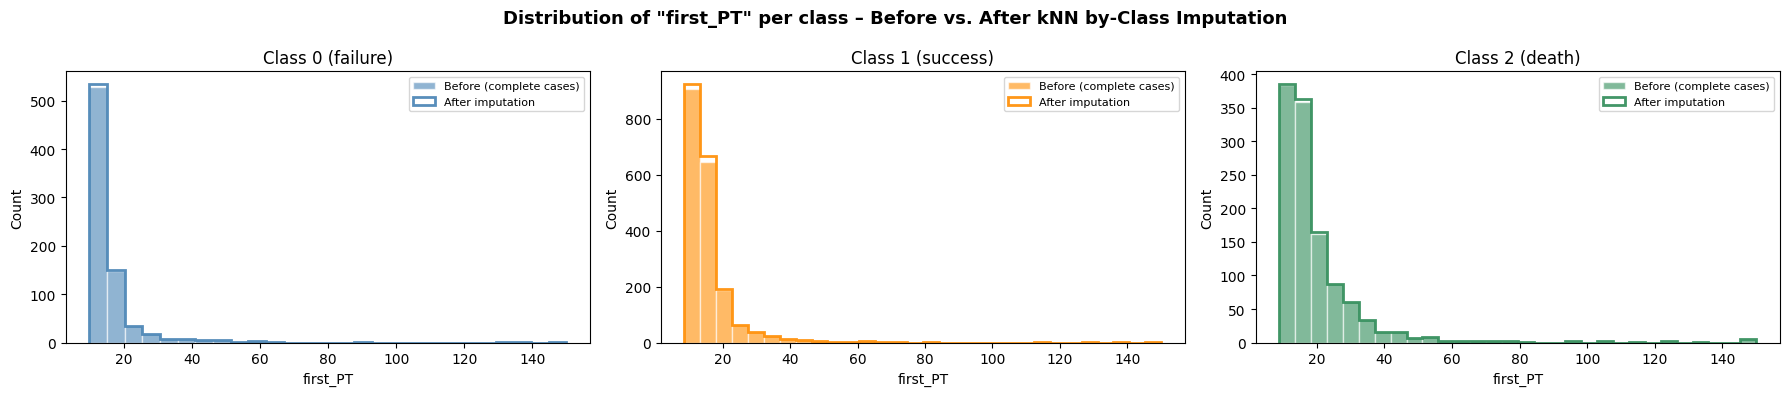

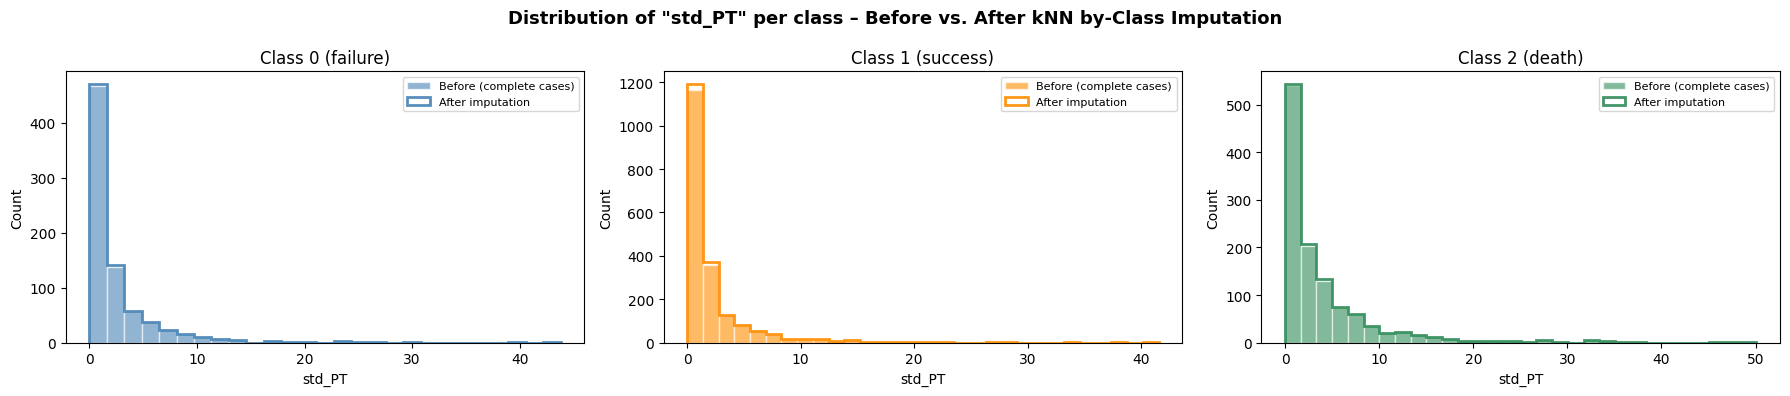

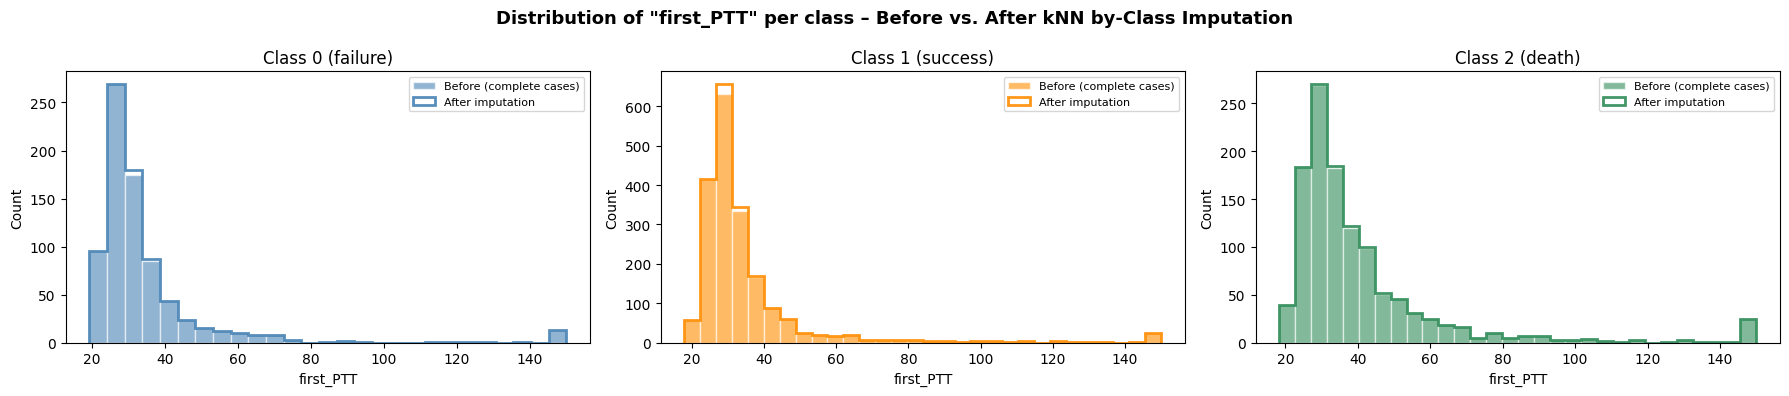

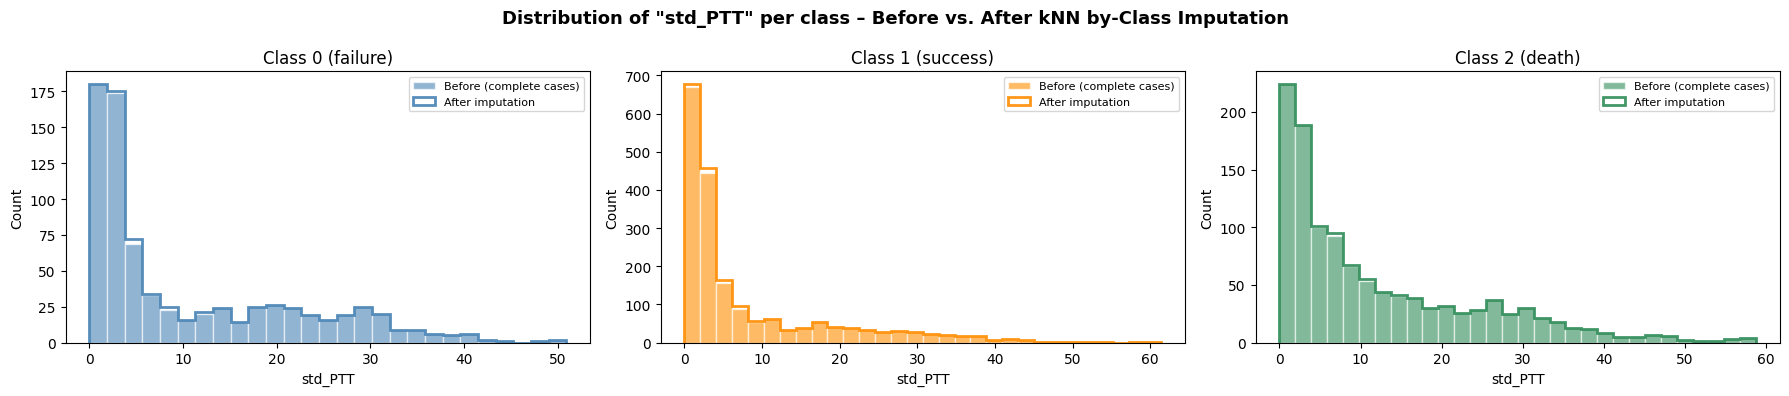

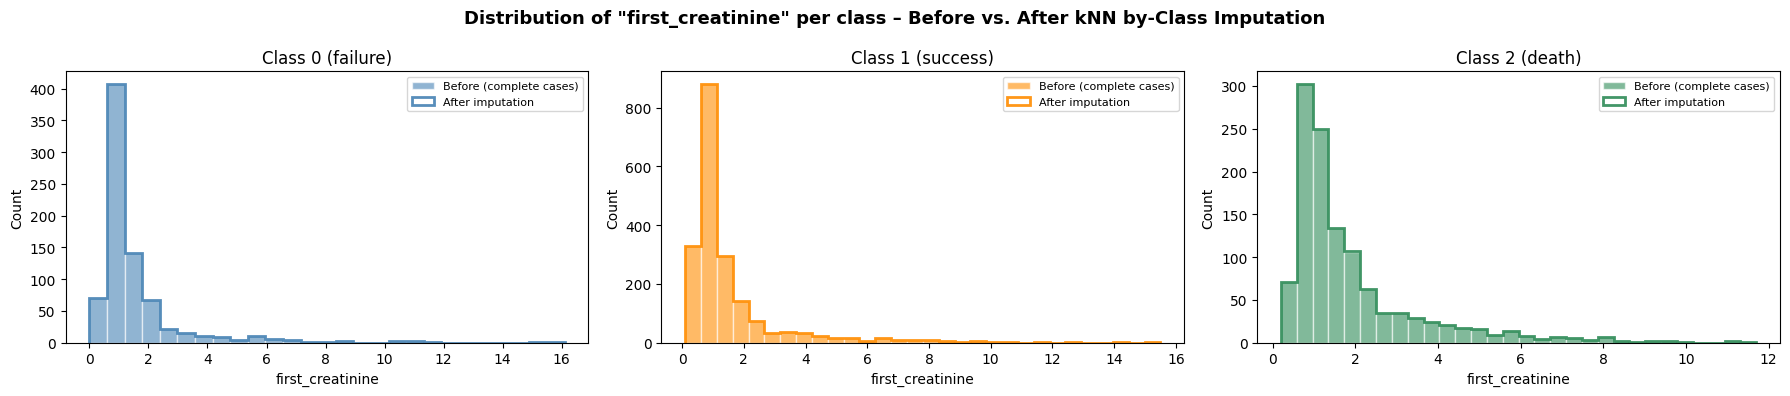

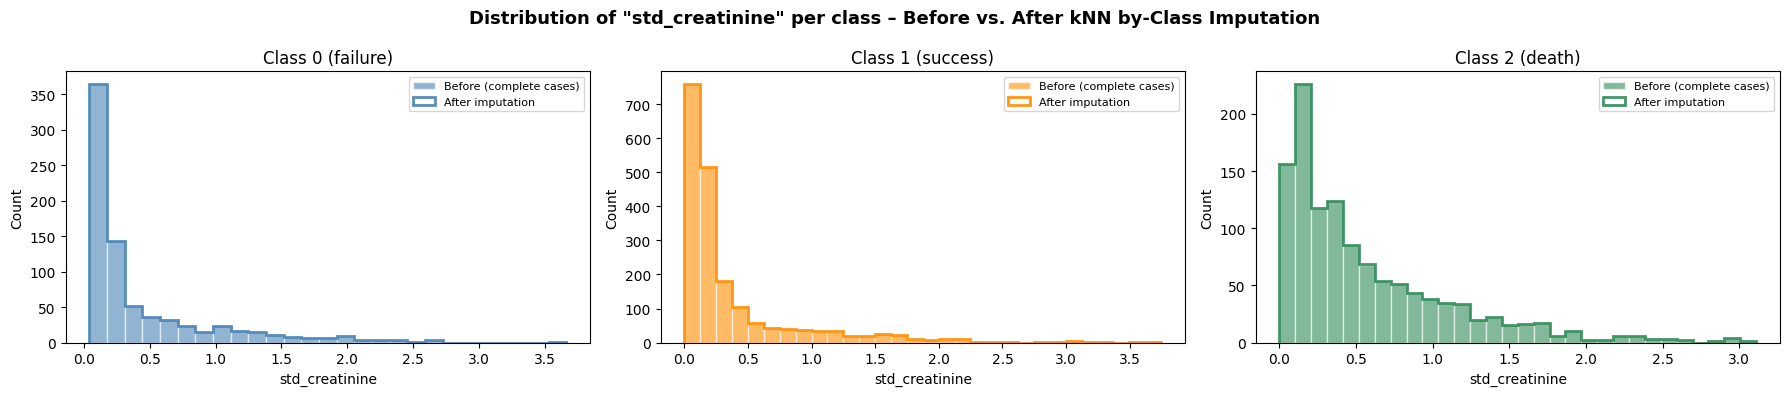

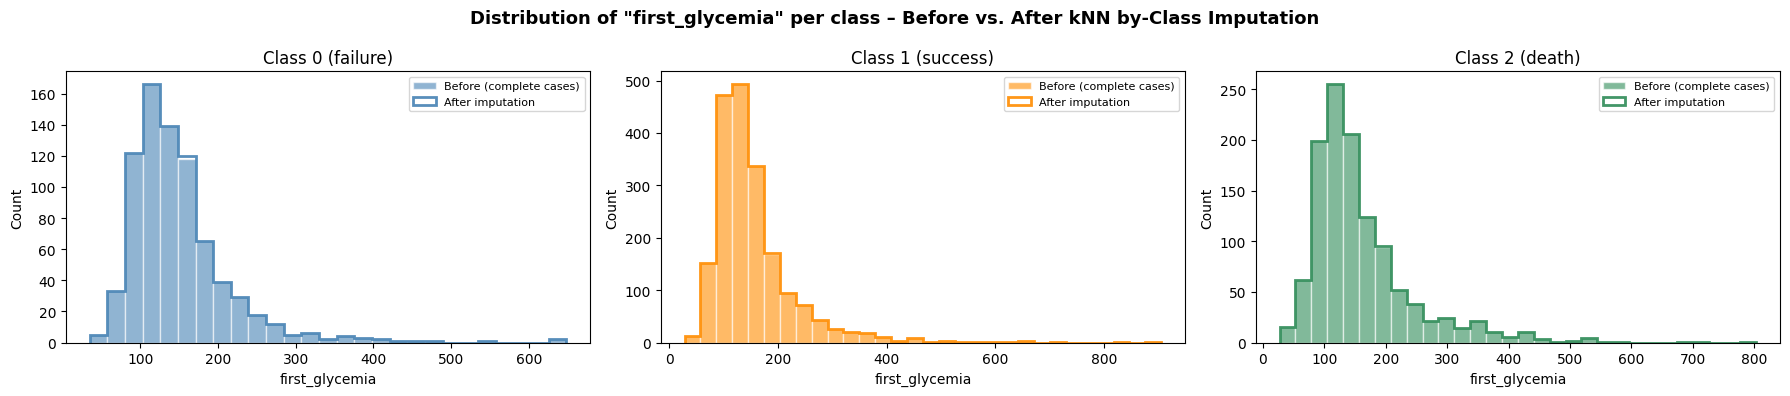

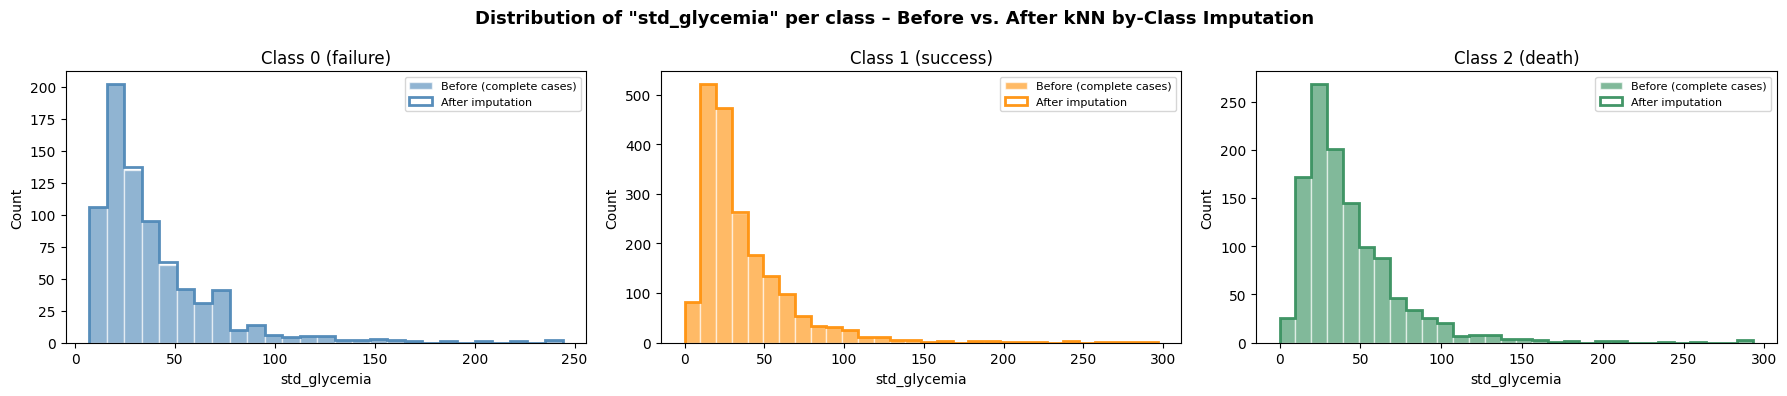

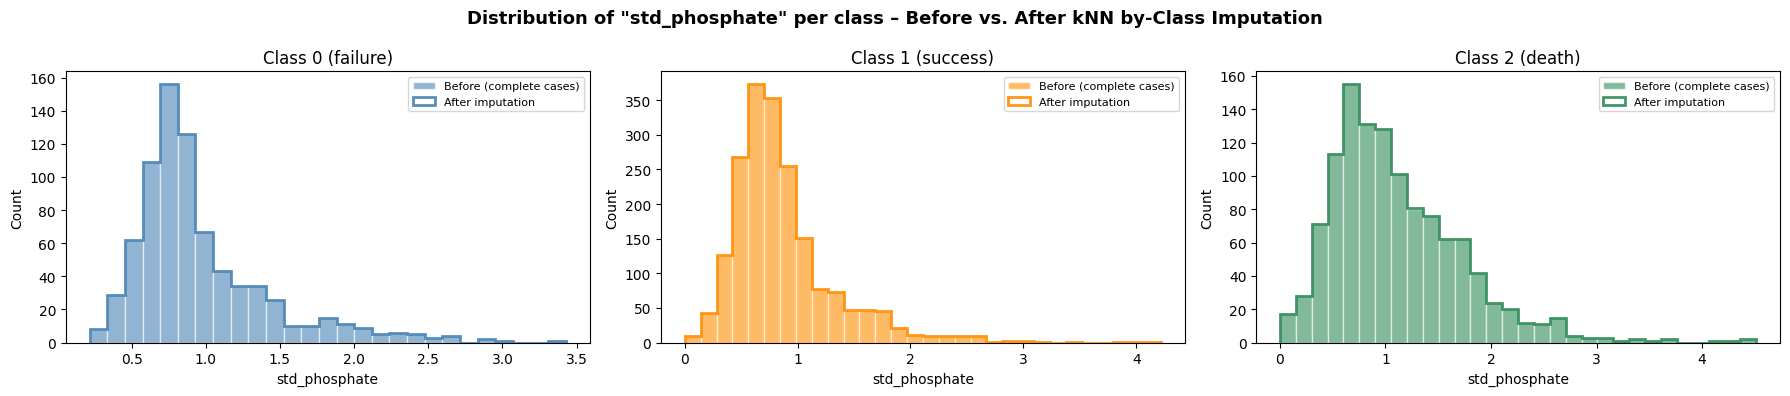

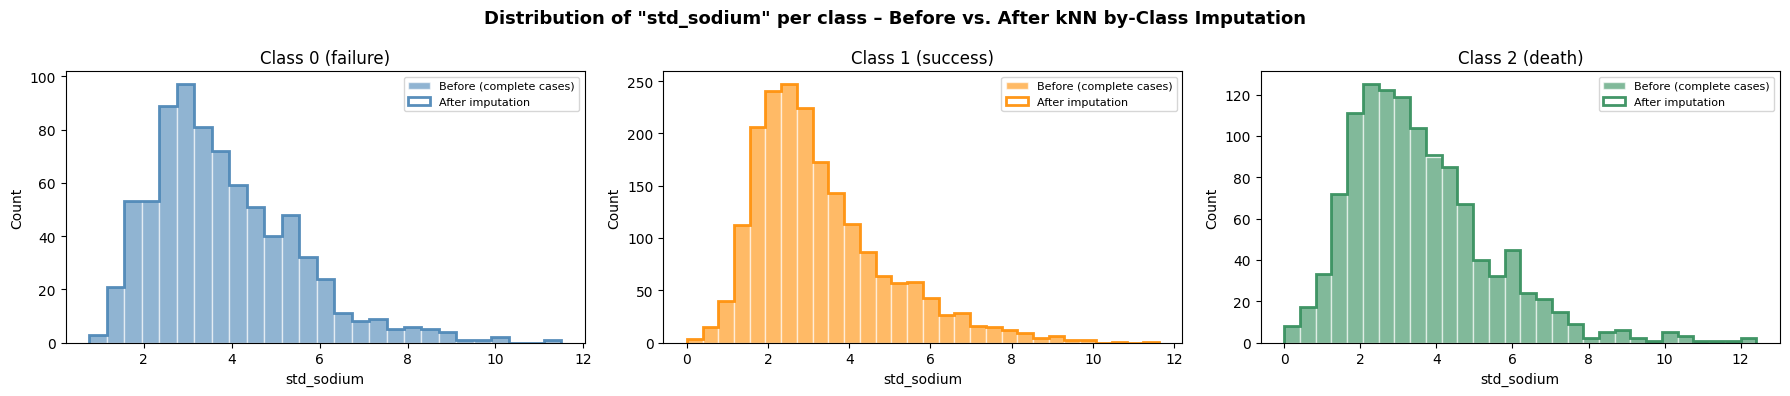

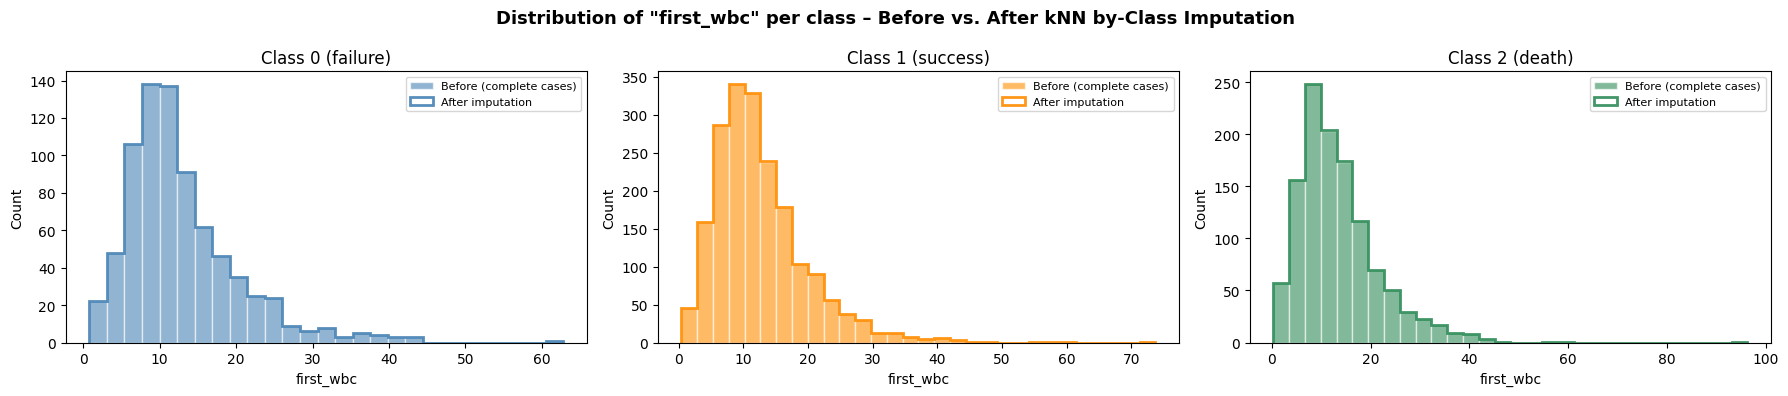

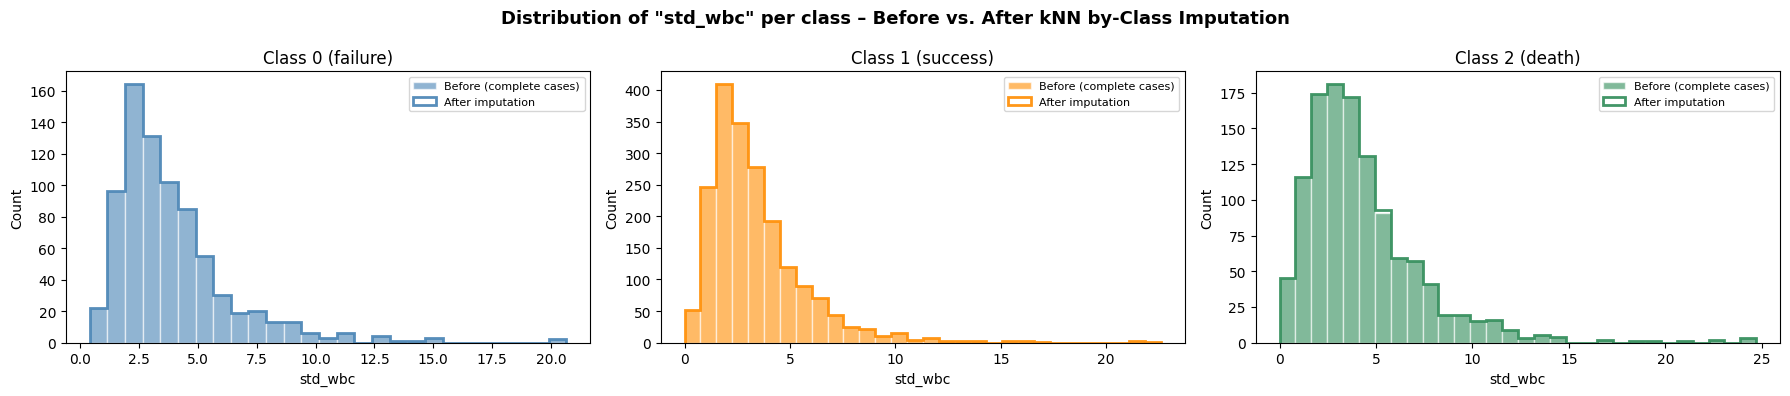

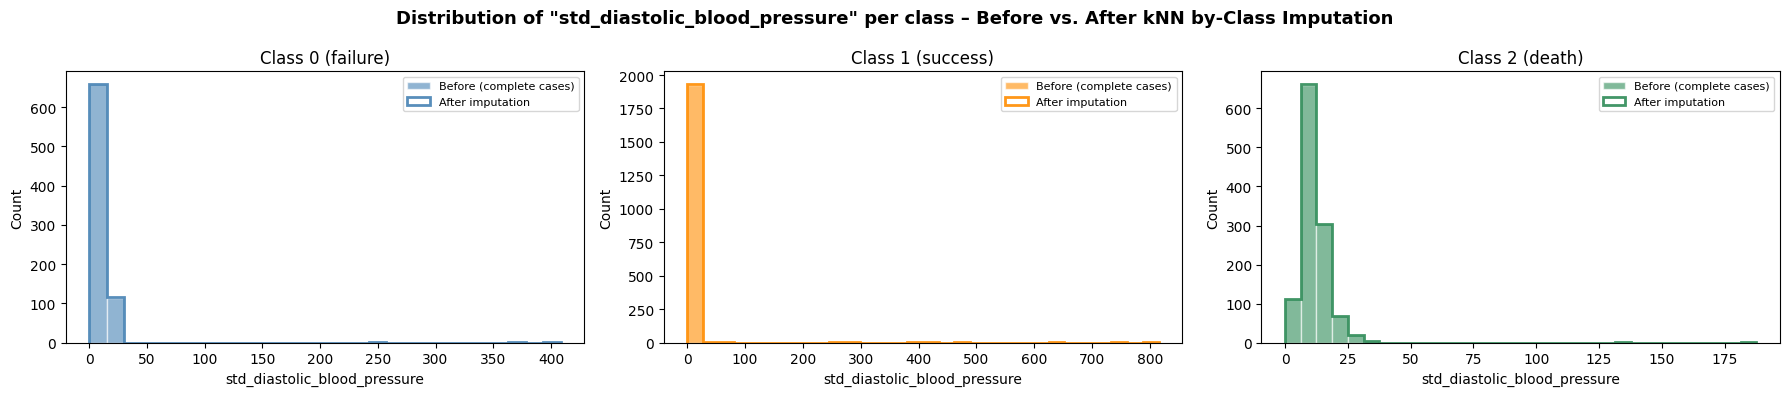

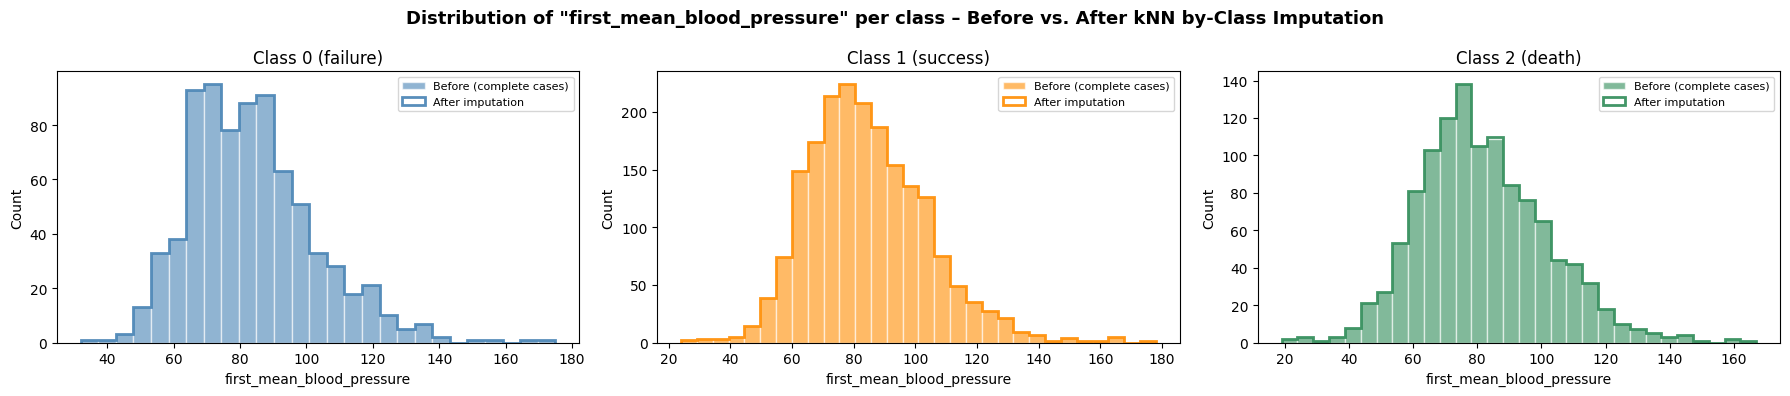

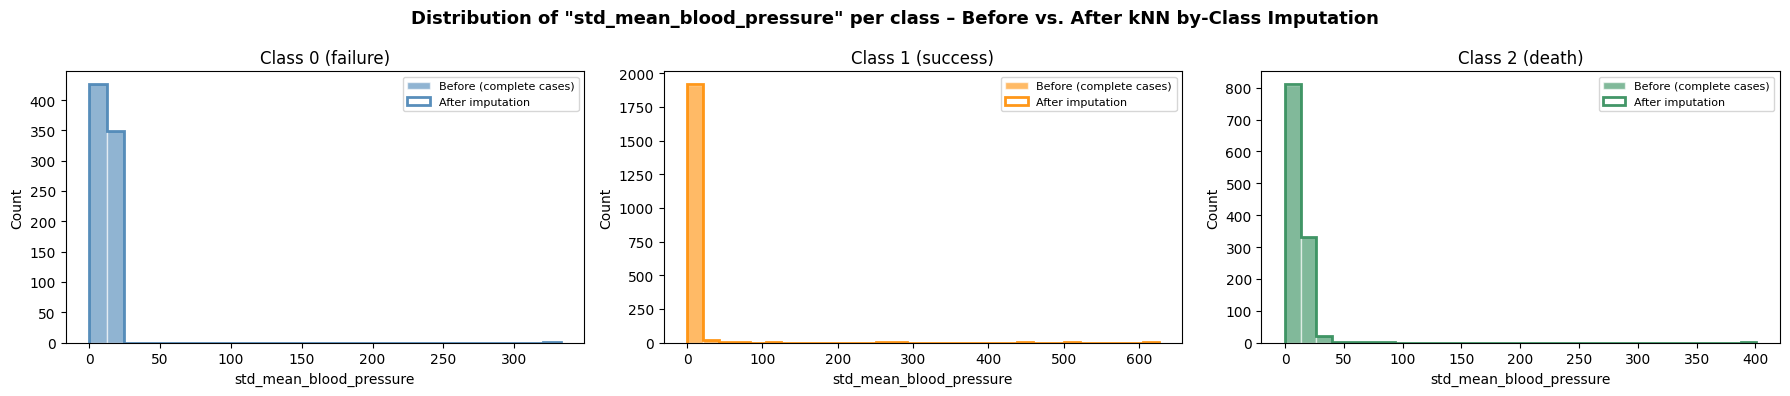

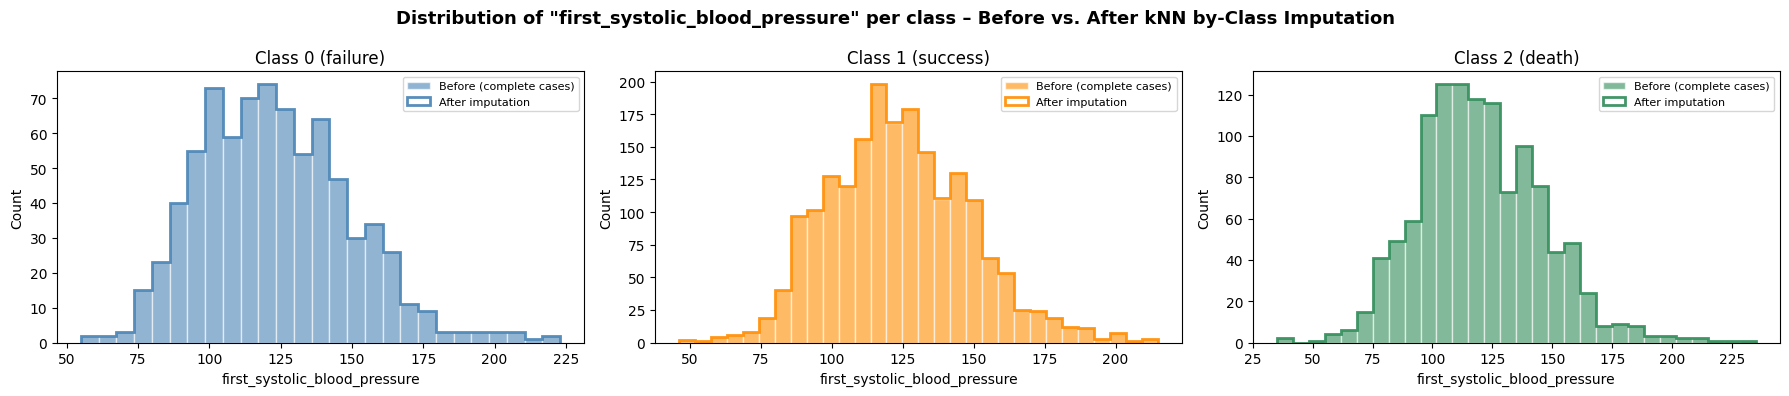

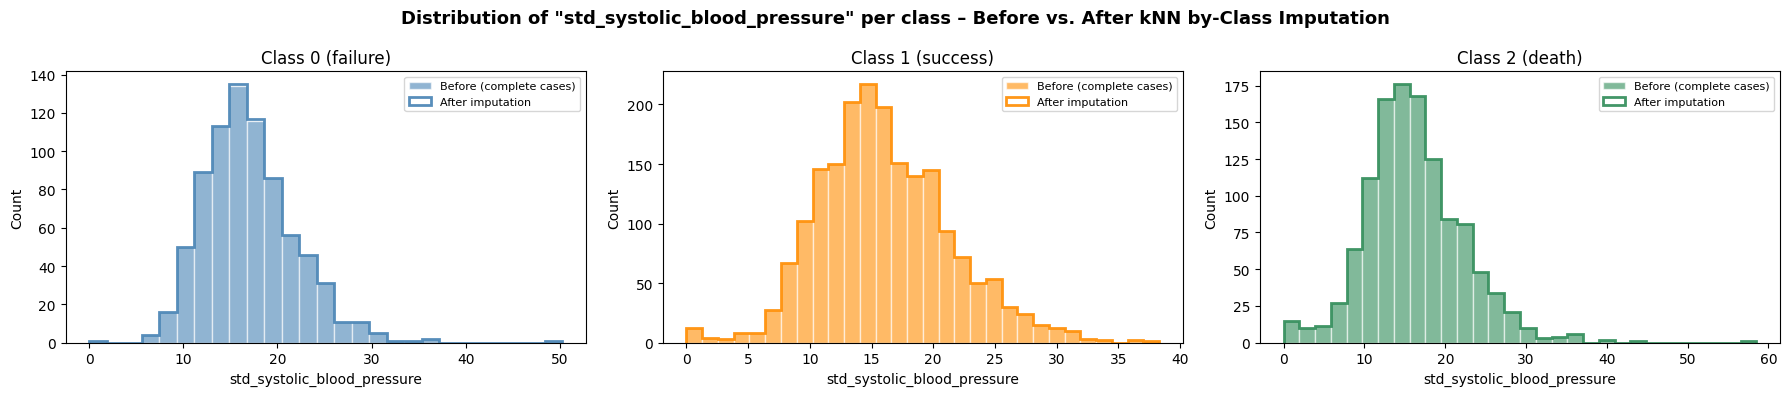

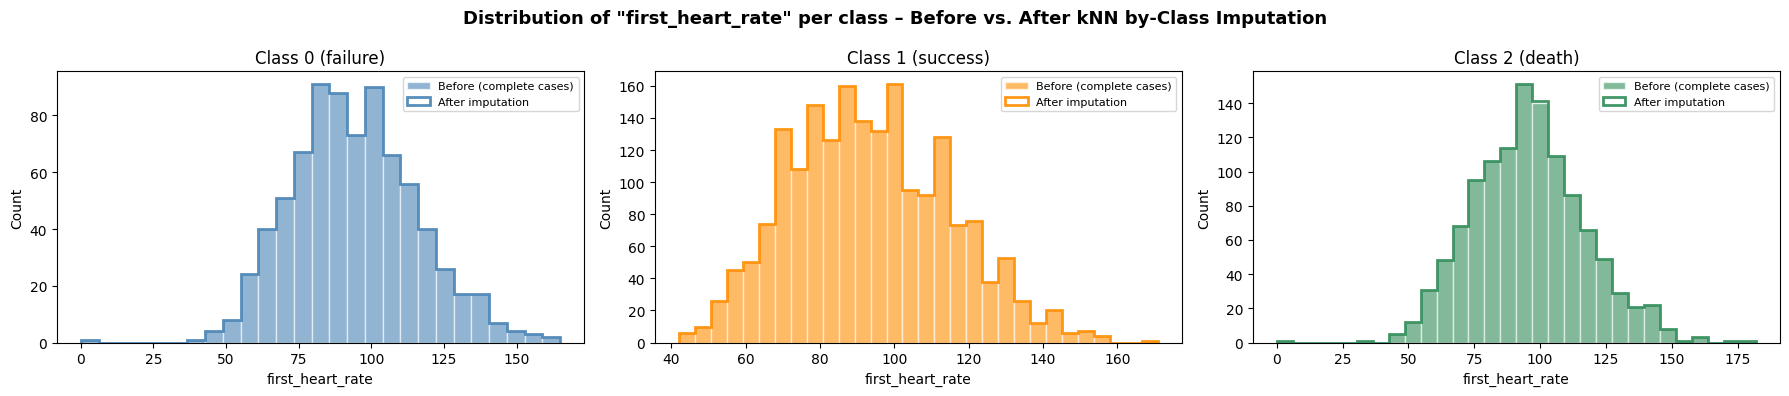

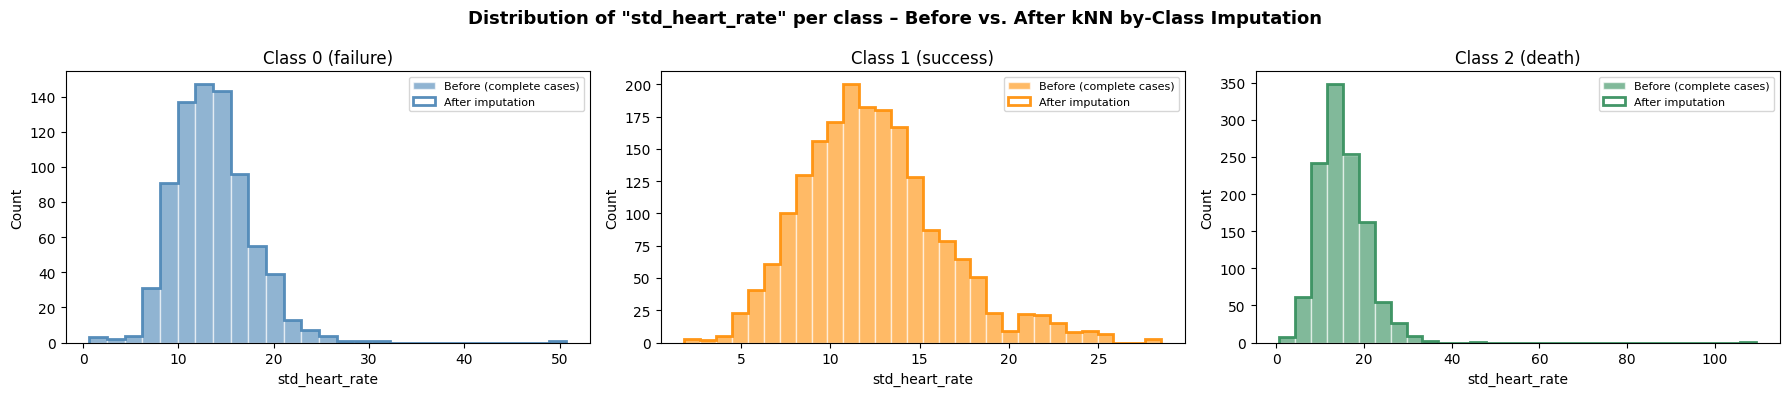

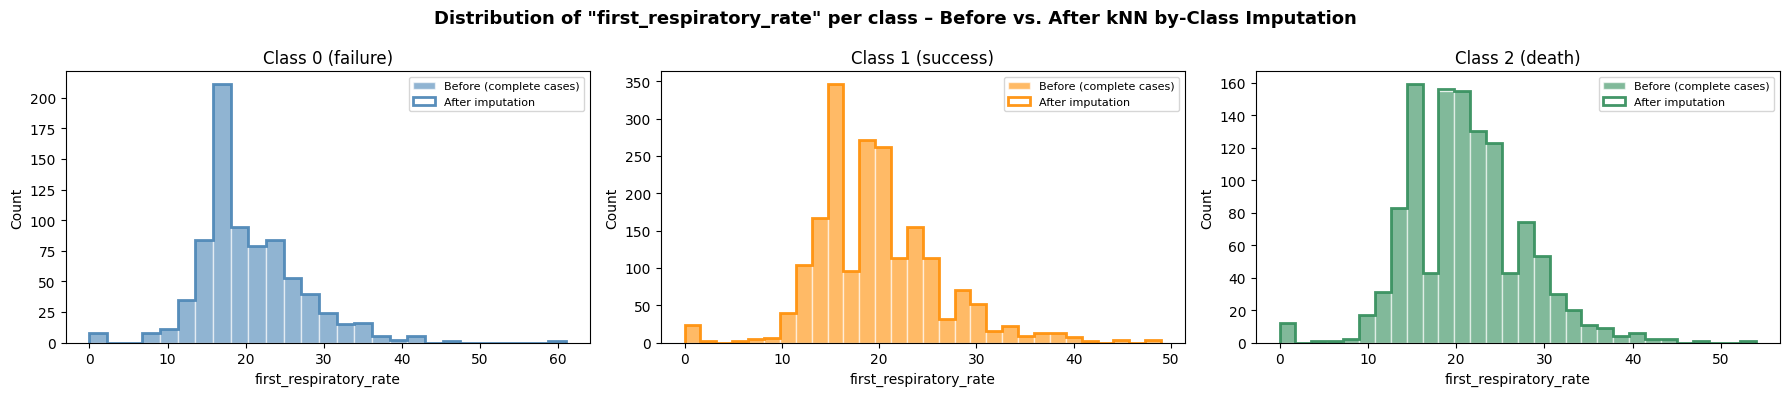

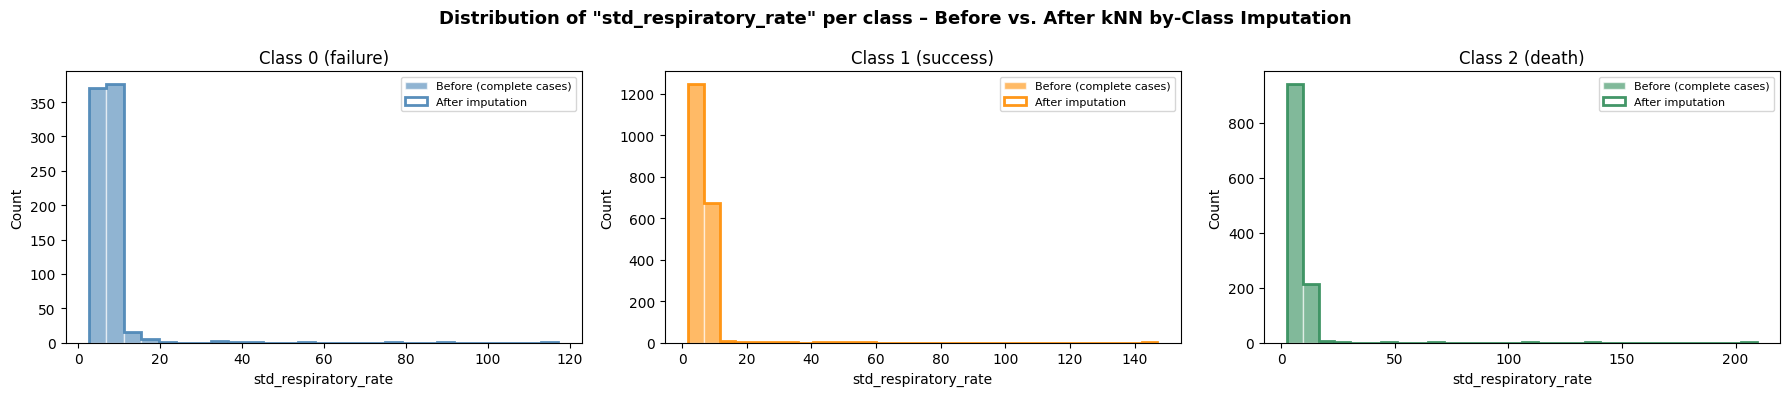

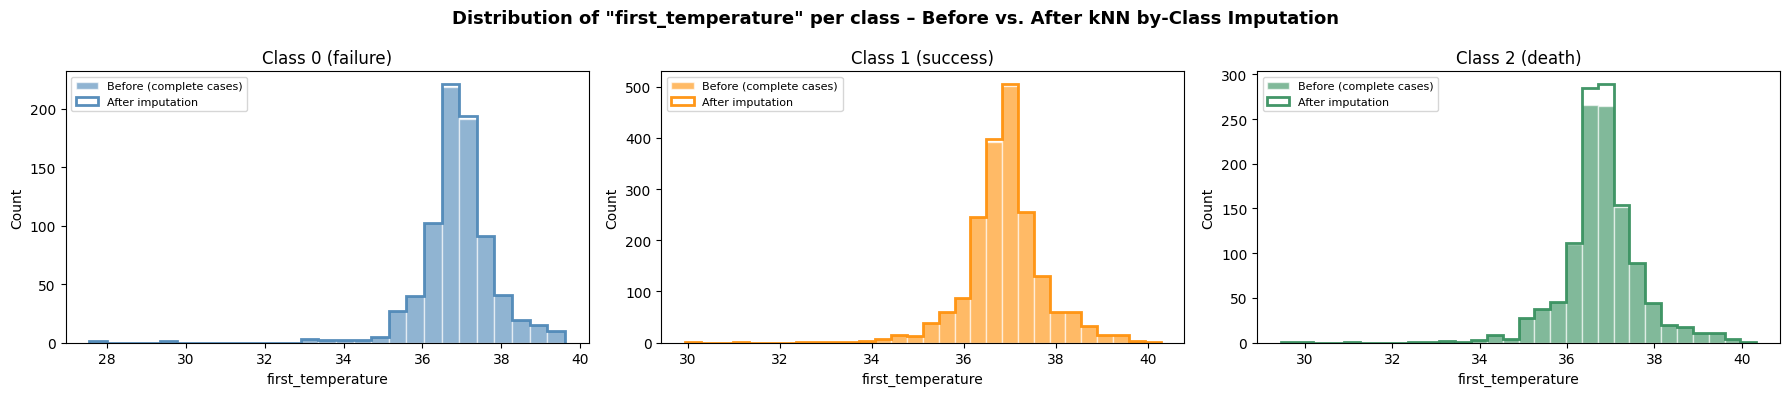

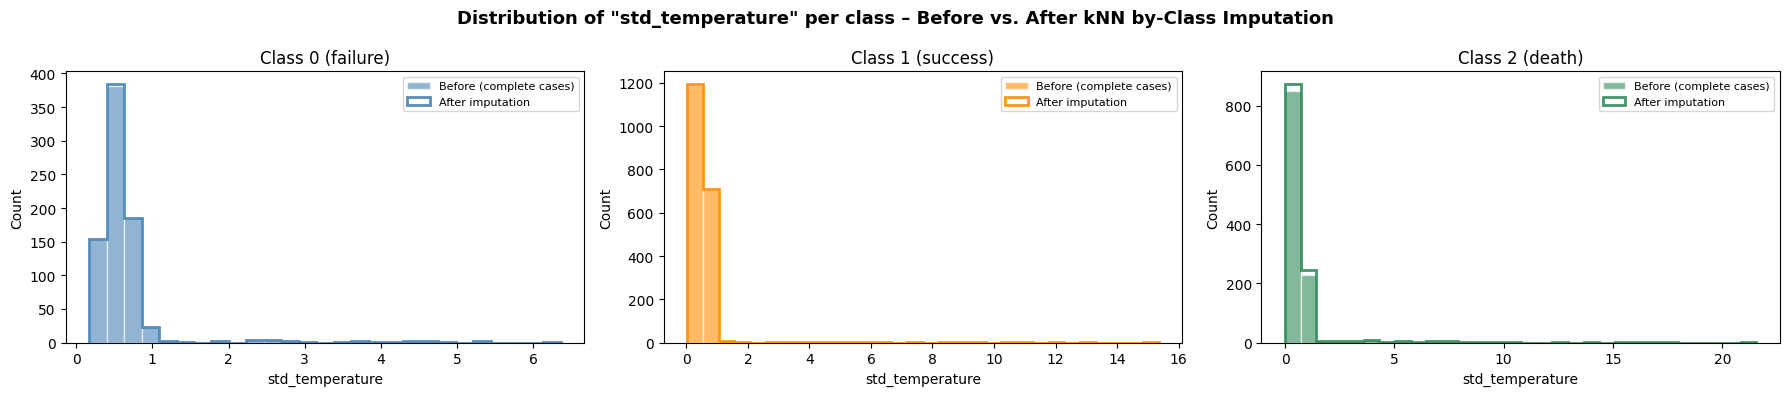

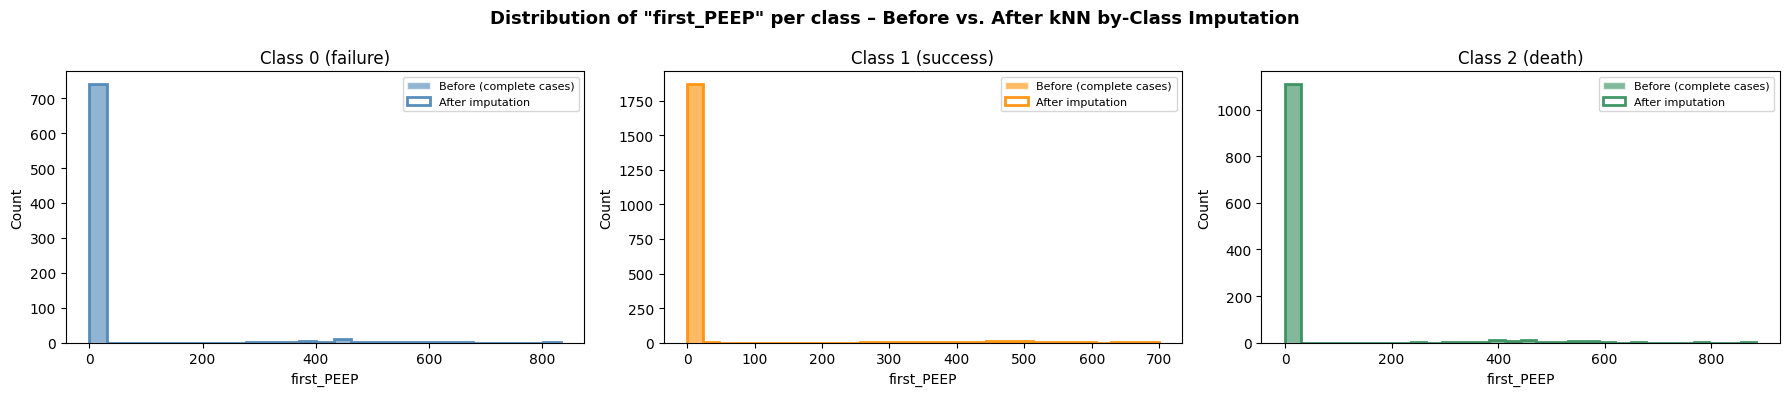

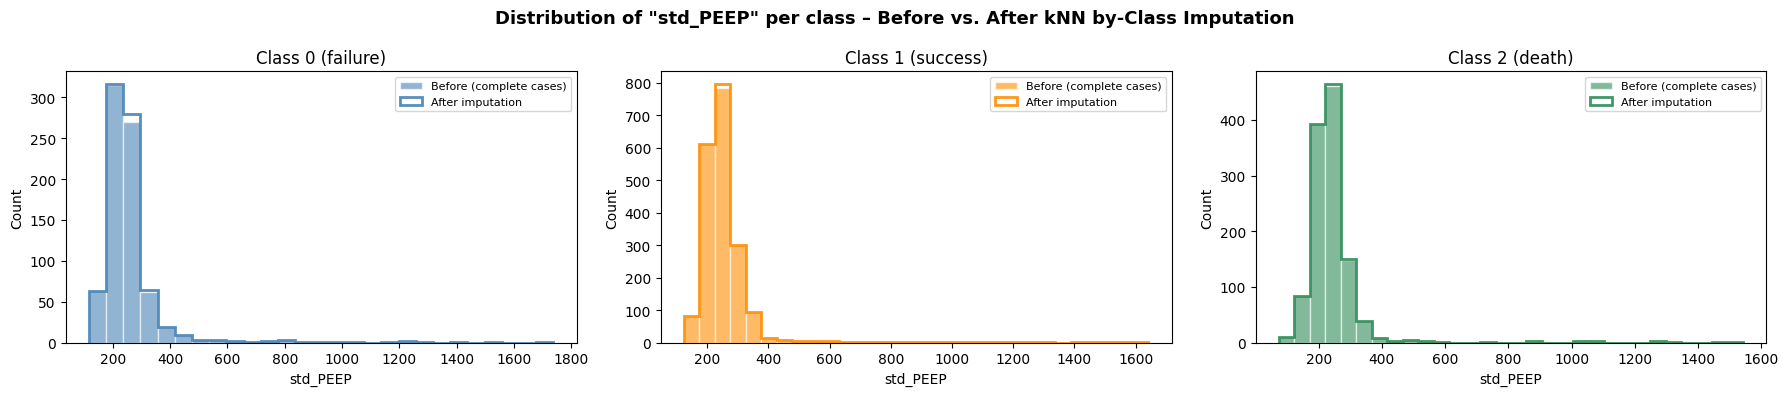

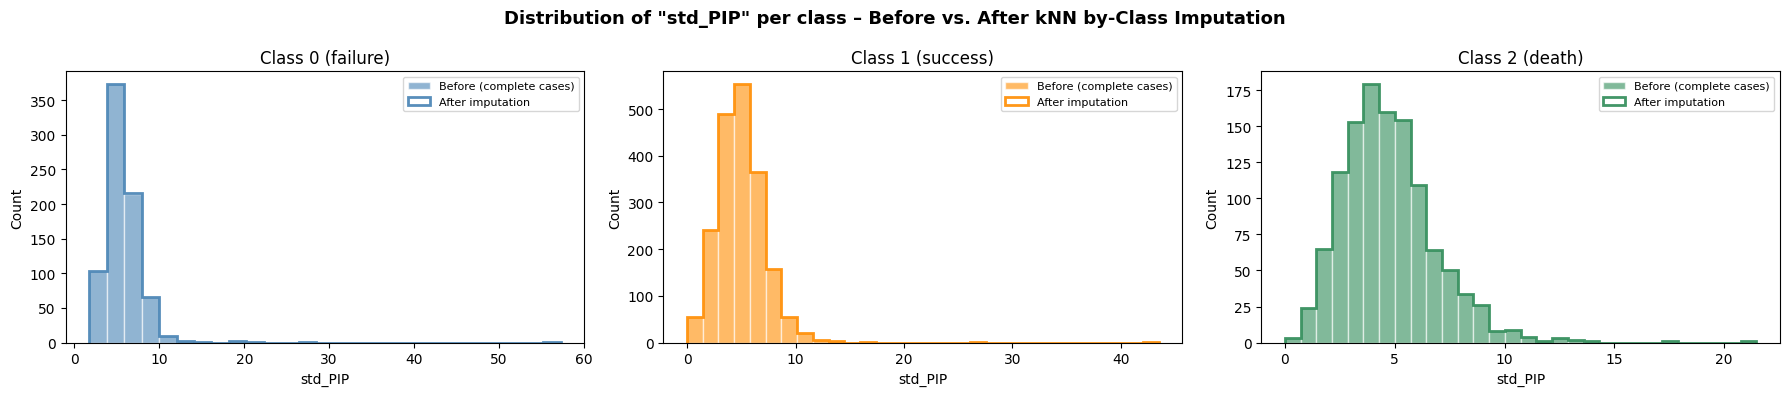

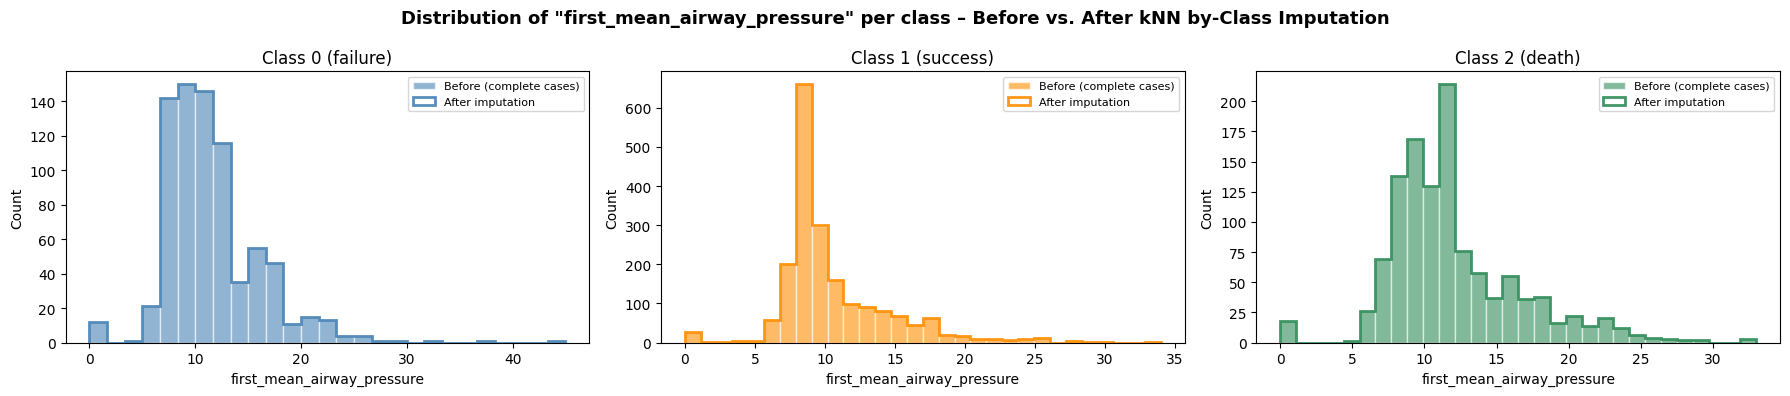

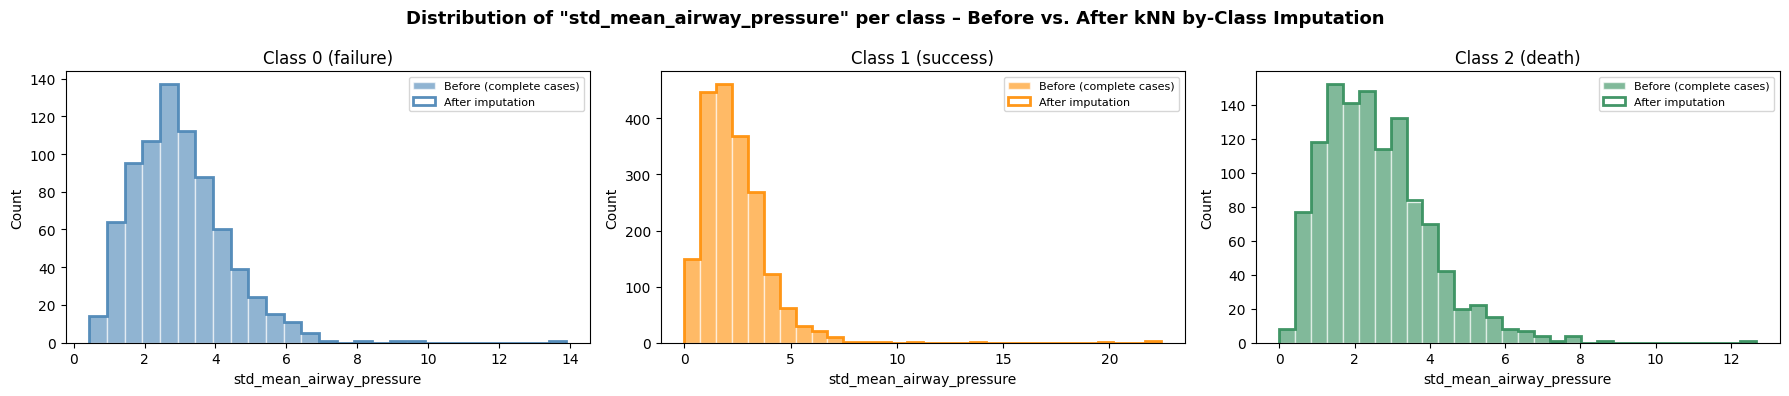

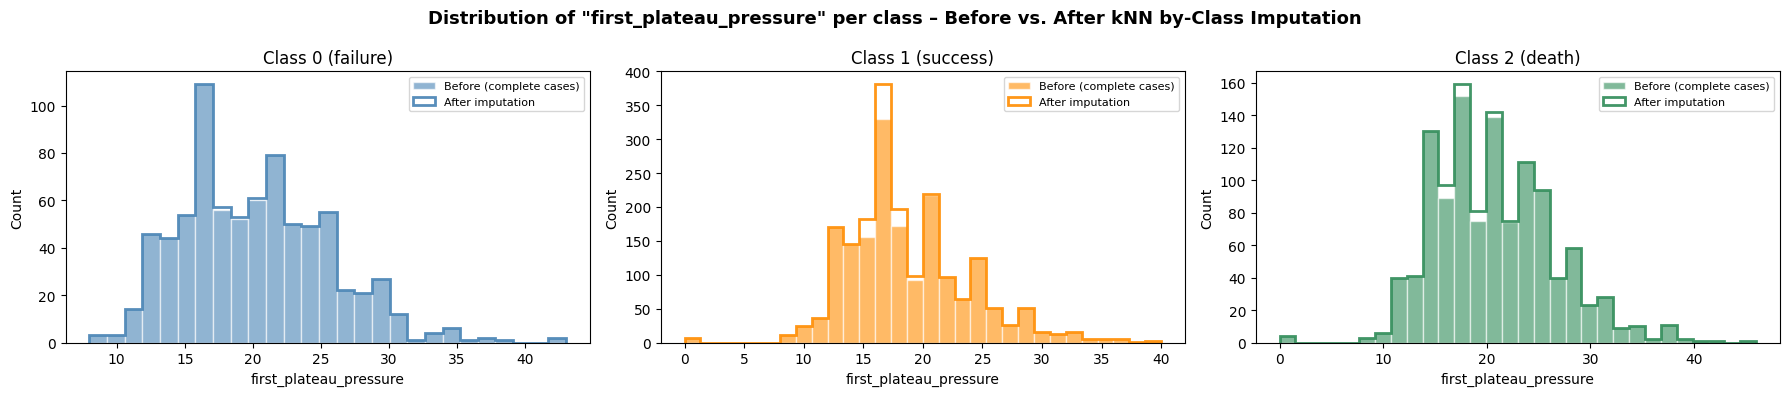

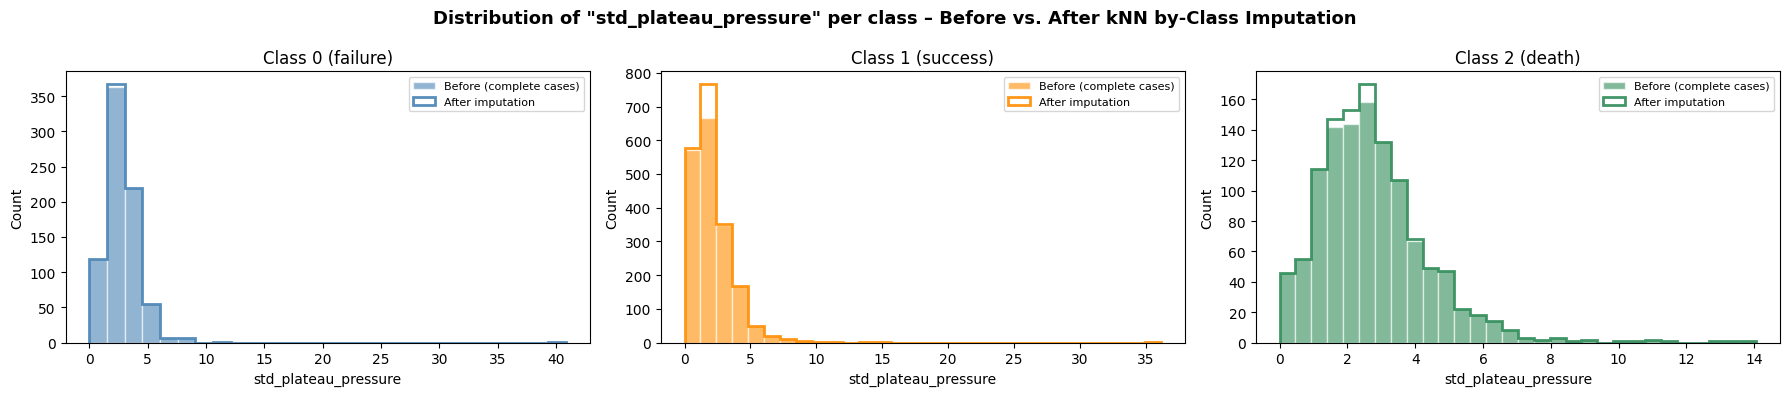

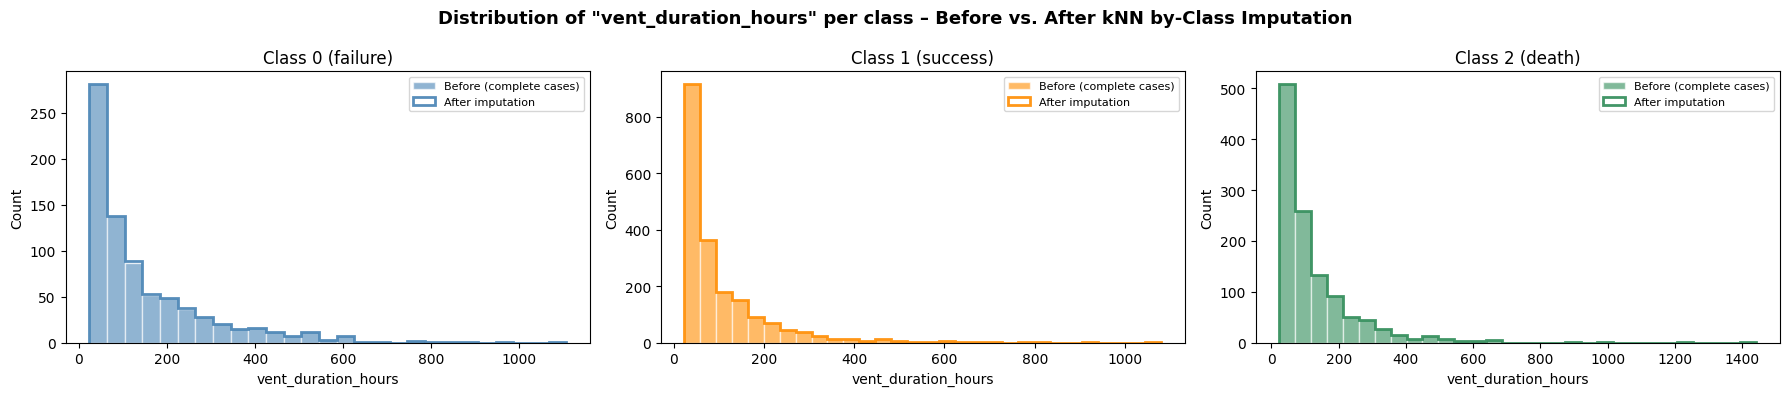

In [15]:
import matplotlib.pyplot as plt

vars_with_mv = [col for col in input_features if df[col].isna().any()]
class_colors = {0: 'steelblue', 1: 'darkorange', 2: 'seagreen'}
class_labels = {0: 'Class 0 (failure)', 1: 'Class 1 (success)', 2: 'Class 2 (death)'}

for col in vars_with_mv:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=False)
    fig.suptitle(
        f'Distribution of "{col}" per class – Before vs. After kNN by-Class Imputation',
        fontsize=13, fontweight='bold'
    )
    for ax, cls in zip(axes, [0, 1, 2]):
        mask   = df['outcome'] == cls
        before = df.loc[mask, col].dropna()
        after  = df_final_by_class.loc[mask, col].dropna()
        bins = min(30, max(5, int(len(after) ** 0.5)))
        ax.hist(before, bins=bins, alpha=0.6,
                color=class_colors[cls], label='Before (complete cases)', edgecolor='white')
        ax.hist(after,  bins=bins, alpha=0.9,
                color=class_colors[cls], label='After imputation',
                histtype='step', linewidth=2)
        ax.set_title(class_labels[cls])
        ax.set_xlabel(col)
        ax.set_ylabel('Count')
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


## Final saving

In [16]:
# Save class-stratified imputed dataset to Excel
new_sheet_name = "Dataset_step_3b"
with pd.ExcelWriter(file_path, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
    df_final_by_class.to_excel(writer, sheet_name=new_sheet_name, index=False)
print(f"Dataset saved to '{new_sheet_name}'")

Dataset saved to 'Dataset_step_3b'
